# Learning Ligand Preferences for Human Acetylcholinesterase

This notebook contains the full QSAR, external screening, docking, and pose-analysis workflow used in the project. It was developed in Google Colab and saves checkpoints to Google Drive so longer sections can be resumed after a runtime disconnect.

The study began as an extension of my interest in molecular docking: I wanted to see what chemical patterns a model trained on ligands for one protein would learn, then compare its external predictions with structure-based docking results.

## 1. Setup

Install the main packages and define the project environment.

In [ ]:
!pip install -q rdkit pandas numpy scikit-learn matplotlib requests joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 26.9 MB/s eta 0:00:00


In [ ]:
import time
import random
import requests
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from google.colab import drive

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, ParameterSampler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

TARGET_NAME = "Human acetylcholinesterase"
TARGET_CHEMBL_ID = "CHEMBL220"
ENDPOINT = "IC50"
ACTIVITY_COLUMN = f"p{ENDPOINT}"

FINGERPRINT_SIZE = 2048
FINGERPRINT_RADIUS = 2
TEST_SIZE = 0.20

print(TARGET_NAME, TARGET_CHEMBL_ID, ENDPOINT)


Human acetylcholinesterase CHEMBL220 IC50


In [ ]:
import os
import time
from google.colab import drive

if os.path.isdir("/content/drive") and not os.path.ismount("/content/drive"):
    os.rename(
        "/content/drive",
        f"/content/drive_stale_{int(time.time())}"
    )

drive.mount("/content/drive")

Mounted at /content/drive


## 2. ChEMBL data collection

Download and save human acetylcholinesterase activity records.

In [ ]:
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/AChE_QSAR_Resumable")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH = PROJECT_DIR / f"{TARGET_CHEMBL_ID}_{ENDPOINT}_raw.csv"
CLEAN_PATH = PROJECT_DIR / f"{TARGET_CHEMBL_ID}_{ENDPOINT}_clean_unique_ligands.csv"
PREPARED_PATH = PROJECT_DIR / "prepared_data.joblib"
BASELINE_MODEL_PATH = PROJECT_DIR / "baseline_rf.joblib"
CV_PATH = PROJECT_DIR / "baseline_cv.joblib"
TUNING_PATH = PROJECT_DIR / "rf_tuning_checkpoint.joblib"
FINAL_MODEL_PATH = PROJECT_DIR / "best_rf.joblib"
PREDICTIONS_PATH = PROJECT_DIR / f"{TARGET_CHEMBL_ID}_{ENDPOINT}_test_predictions.csv"

print(PROJECT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/AChE_QSAR_Resumable


In [ ]:
activity_url = "https://www.ebi.ac.uk/chembl/api/data/activity.json"

for endpoint in ["IC50", "Ki", "Kd", "EC50"]:
    response = requests.get(
        activity_url,
        params={
            "target_chembl_id": TARGET_CHEMBL_ID,
            "standard_type": endpoint,
            "limit": 1
        },
        timeout=120
    )
    response.raise_for_status()
    print(endpoint, response.json()["page_meta"]["total_count"])


IC50 10079
Ki 1970
Kd 296
EC50 63


In [ ]:
if RAW_PATH.exists():
    activity_df = pd.read_csv(RAW_PATH)
    print("Raw data restored:", len(activity_df))
else:
    records = []
    offset = 0
    limit = 500

    while True:
        response = None

        for attempt in range(10):
            try:
                response = requests.get(
                    activity_url,
                    params={
                        "target_chembl_id": TARGET_CHEMBL_ID,
                        "standard_type": ENDPOINT,
                        "limit": limit,
                        "offset": offset
                    },
                    timeout=180
                )

                if response.status_code == 200:
                    break

                print("Offset", offset, "attempt", attempt + 1, "status", response.status_code, flush=True)

            except requests.RequestException as error:
                print("Offset", offset, "attempt", attempt + 1, type(error).__name__, flush=True)

            time.sleep(5)

        if response is None or response.status_code != 200:
            raise RuntimeError(f"Download failed at offset {offset}")

        page = response.json()["activities"]

        if not page:
            break

        records.extend(page)
        offset += len(page)
        print("Downloaded", len(records), flush=True)

        if len(page) < limit:
            break

        time.sleep(1)

    activity_df = pd.DataFrame(records)
    activity_df.to_csv(RAW_PATH, index=False)
    print("Raw data saved:", len(activity_df))


Raw data restored: 10079


## 3. Data cleaning and standardization

Inspect endpoints, standardize structures, remove duplicates, and prepare pIC50 values.

In [ ]:
print(activity_df["standard_type"].value_counts(dropna=False))
print(activity_df["standard_units"].value_counts(dropna=False).head(10))
print(activity_df["standard_relation"].value_counts(dropna=False))
print("Unique molecule IDs:", activity_df["molecule_chembl_id"].nunique())


standard_type
IC50    10079
Name: count, dtype: int64
standard_units
nM             8723
NaN            1265
ug.mL-1          83
10'5pM            3
10'6pM            2
10^-4microM       2
10'3pM            1
Name: count, dtype: int64
standard_relation
=      7901
NaN    1286
>       875
<        13
~         2
>>        2
Name: count, dtype: int64
Unique molecule IDs: 8372


In [ ]:
if CLEAN_PATH.exists():
    final_df = pd.read_csv(CLEAN_PATH)
    print("Clean ligands restored:", len(final_df))
else:
    clean_df = activity_df.copy()

    clean_df = clean_df[
        (clean_df["standard_relation"] == "=") &
        (clean_df["standard_units"] == "nM") &
        (clean_df["canonical_smiles"].notna()) &
        (clean_df["standard_value"].notna()) &
        (clean_df["data_validity_comment"].isna())
    ].copy()

    clean_df["standard_value"] = pd.to_numeric(clean_df["standard_value"], errors="coerce")

    clean_df = clean_df[
        clean_df["standard_value"].notna() &
        (clean_df["standard_value"] > 0)
    ].copy()

    clean_df[ACTIVITY_COLUMN] = 9 - np.log10(clean_df["standard_value"])

    final_df = (
        clean_df
        .groupby(["molecule_chembl_id", "canonical_smiles"], as_index=False)
        .agg({ACTIVITY_COLUMN: "median", "standard_value": "count"})
        .rename(columns={"standard_value": "measurement_count"})
    )

    final_df.to_csv(CLEAN_PATH, index=False)
    print("Clean measurements:", len(clean_df))
    print("Final unique ligands:", len(final_df))

display(final_df.head())


Clean ligands restored: 5830


,molecule_chembl_id,canonical_smiles,pIC50,measurement_count
0,CHEMBL100334,CN(CCOCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,6.920819,1
1,CHEMBL100366,CN1CC[C@@]2(C)c3cc(OC(=O)Nc4ccccc4)ccc3N(C=O)C12,6.107683,1
2,CHEMBL100510,CN(CCOCCNC(=S)NC(=O)c1ccc2ccccc2c1)Cc1ccccc1,7.000000,1
3,CHEMBL101028,CN(CCOCCNC(=S)Nc1ccc(OC(F)(F)F)cc1)Cc1ccccc1,6.000000,1
4,CHEMBL101155,CN(CCOCCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,5.958607,1


## 4. Fingerprints and train-test split

Generate Morgan fingerprints and prepare the first model split.

In [ ]:
if PREPARED_PATH.exists():
    prepared = joblib.load(PREPARED_PATH)
    X_train = prepared["X_train"]
    X_test = prepared["X_test"]
    y_train = prepared["y_train"]
    y_test = prepared["y_test"]
    train_idx = prepared["train_idx"]
    test_idx = prepared["test_idx"]
    final_df = prepared["final_df"]
    print("Prepared arrays restored.")
else:
    generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=FINGERPRINT_RADIUS,
        fpSize=FINGERPRINT_SIZE
    )

    fingerprints = []
    valid_rows = []

    for _, row in final_df.iterrows():
        mol = Chem.MolFromSmiles(row["canonical_smiles"])

        if mol is None:
            continue

        fingerprints.append(generator.GetFingerprintAsNumPy(mol))
        valid_rows.append(row.to_dict())

    final_df = pd.DataFrame(valid_rows).reset_index(drop=True)
    X = np.asarray(fingerprints, dtype=np.uint8)
    y = final_df[ACTIVITY_COLUMN].to_numpy(dtype=np.float32)
    indices = np.arange(len(final_df))

    X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
        X,
        y,
        indices,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED
    )

    joblib.dump(
        {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "train_idx": train_idx,
            "test_idx": test_idx,
            "final_df": final_df
        },
        PREPARED_PATH,
        compress=3
    )

    print("Prepared arrays saved.")

print("Training:", X_train.shape)
print("Testing:", X_test.shape)


Prepared arrays restored.
Training: (4664, 2048)
Testing: (1166, 2048)


## Baseline random forest

The model is saved to Drive and restored after a runtime restart.


## 5. Random forest development

Fit the baseline model, run cross-validation, tune the main hyperparameters, and evaluate the final model.

In [ ]:
if BASELINE_MODEL_PATH.exists():
    baseline_rf = joblib.load(BASELINE_MODEL_PATH)
    print("Baseline model restored.")
else:
    baseline_rf = RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    baseline_rf.fit(X_train, y_train)
    joblib.dump(baseline_rf, BASELINE_MODEL_PATH, compress=3)
    print("Baseline model trained and saved.")

baseline_predictions = baseline_rf.predict(X_test)

print("Baseline test R²:", round(r2_score(y_test, baseline_predictions), 3))
print("Baseline test RMSE:", round(np.sqrt(mean_squared_error(y_test, baseline_predictions)), 3))
print("Baseline test MAE:", round(mean_absolute_error(y_test, baseline_predictions), 3))


Baseline model restored.
Baseline test R²: 0.703
Baseline test RMSE: 0.715
Baseline test MAE: 0.506


## Resumable five-fold cross-validation

Every completed fold is saved.


In [ ]:
kf5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

if CV_PATH.exists():
    cv_state = joblib.load(CV_PATH)
    print("Cross-validation checkpoint restored.")
else:
    cv_state = {"scores": {}}
    joblib.dump(cv_state, CV_PATH)

for fold_number, (fit_idx, validation_idx) in enumerate(kf5.split(X_train), start=1):
    key = str(fold_number)

    if key in cv_state["scores"]:
        print(f"Fold {fold_number}/5 restored | R² = {cv_state['scores'][key]:.3f}", flush=True)
        continue

    fold_start = time.time()
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=-1
    )
    model.fit(X_train[fit_idx], y_train[fit_idx])
    score = model.score(X_train[validation_idx], y_train[validation_idx])

    cv_state["scores"][key] = float(score)
    joblib.dump(cv_state, CV_PATH)

    print(
        f"Fold {fold_number}/5 saved | R² = {score:.3f} | minutes = {(time.time() - fold_start) / 60:.1f}",
        flush=True
    )

cv_scores = np.array([cv_state["scores"][str(i)] for i in range(1, 6)])

print("Cross-validation scores:", cv_scores)
print("Mean CV R²:", round(cv_scores.mean(), 3))
print("CV standard deviation:", round(cv_scores.std(), 3))


Cross-validation checkpoint restored.
Fold 1/5 restored | R² = 0.674
Fold 2/5 restored | R² = 0.687
Fold 3/5 restored | R² = 0.693
Fold 4/5 restored | R² = 0.657
Fold 5/5 restored | R² = 0.630
Cross-validation scores: [0.67399516 0.6874673  0.69321939 0.65689957 0.62965914]
Mean CV R²: 0.668
CV standard deviation: 0.023


## Resumable staged hyperparameter search

This search tests 12 broad candidates with 100 trees, advances the best four to 300 trees, and gives the best two 800 trees. It uses three-fold cross-validation, prints every 50 trees, and saves every completed fold.


In [ ]:
param_distributions = {
    "max_depth": [None, 20, 40, 60],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 1.0]
}

candidates = list(
    ParameterSampler(
        param_distributions,
        n_iter=12,
        random_state=RANDOM_SEED
    )
)

stages = [
    {"n_estimators": 100, "keep": 4},
    {"n_estimators": 300, "keep": 2},
    {"n_estimators": 800, "keep": 1}
]

kf3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

if TUNING_PATH.exists():
    tuning_state = joblib.load(TUNING_PATH)
    print("Tuning checkpoint restored.")
else:
    tuning_state = {
        "active_ids": list(range(len(candidates))),
        "stage_index": 0,
        "fold_scores": {},
        "stage_scores": {}
    }
    joblib.dump(tuning_state, TUNING_PATH)

for stage_index in range(tuning_state["stage_index"], len(stages)):
    stage = stages[stage_index]
    n_estimators = stage["n_estimators"]
    active_ids = tuning_state["active_ids"]

    print(
        f"Stage {stage_index + 1}/{len(stages)} | candidates = {len(active_ids)} | trees = {n_estimators}",
        flush=True
    )

    for position, candidate_id in enumerate(active_ids, start=1):
        params = candidates[candidate_id]
        scores = []

        print(
            f"Candidate {position}/{len(active_ids)} | ID = {candidate_id} | {params}",
            flush=True
        )

        for fold_number, (fit_idx, validation_idx) in enumerate(kf3.split(X_train), start=1):
            key = f"{stage_index}:{candidate_id}:{fold_number}"

            if key in tuning_state["fold_scores"]:
                score = tuning_state["fold_scores"][key]
                scores.append(score)
                print(f"Fold {fold_number}/3 restored | R² = {score:.3f}", flush=True)
                continue

            model = RandomForestRegressor(
                n_estimators=0,
                warm_start=True,
                random_state=RANDOM_SEED + candidate_id * 10 + fold_number,
                n_jobs=-1,
                **params
            )

            fold_start = time.time()

            for tree_count in range(50, n_estimators + 50, 50):
                current_trees = min(tree_count, n_estimators)
                model.set_params(n_estimators=current_trees)
                model.fit(X_train[fit_idx], y_train[fit_idx])

                print(
                    f"Stage {stage_index + 1} | candidate {position}/{len(active_ids)} | fold {fold_number}/3 | trees {current_trees}/{n_estimators}",
                    flush=True
                )

                if current_trees == n_estimators:
                    break

            score = model.score(X_train[validation_idx], y_train[validation_idx])
            tuning_state["fold_scores"][key] = float(score)
            joblib.dump(tuning_state, TUNING_PATH)
            scores.append(float(score))

            print(
                f"Fold {fold_number}/3 saved | R² = {score:.3f} | minutes = {(time.time() - fold_start) / 60:.1f}",
                flush=True
            )

        mean_score = float(np.mean(scores))
        stage_key = f"{stage_index}:{candidate_id}"
        tuning_state["stage_scores"][stage_key] = mean_score
        joblib.dump(tuning_state, TUNING_PATH)
        print(f"Candidate mean CV R² = {mean_score:.3f}", flush=True)

    ranked_ids = sorted(
        active_ids,
        key=lambda candidate_id: tuning_state["stage_scores"][f"{stage_index}:{candidate_id}"],
        reverse=True
    )

    tuning_state["active_ids"] = ranked_ids[:stage["keep"]]
    tuning_state["stage_index"] = stage_index + 1
    joblib.dump(tuning_state, TUNING_PATH)

    print(f"Stage saved | advancing candidate IDs {tuning_state['active_ids']}", flush=True)

best_candidate_id = tuning_state["active_ids"][0]
best_params = candidates[best_candidate_id]
best_internal_cv_r2 = tuning_state["stage_scores"][f"{len(stages) - 1}:{best_candidate_id}"]

print("Best parameters:", best_params)
print("Best internal CV R²:", round(best_internal_cv_r2, 3))


Tuning checkpoint restored.
Best parameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 60}
Best internal CV R²: 0.66


## Final tuned model

The final 800-tree model is saved every 100 trees.


In [ ]:
if FINAL_MODEL_PATH.exists():
    best_rf = joblib.load(FINAL_MODEL_PATH)
    print("Final model restored with", best_rf.n_estimators, "trees.")
else:
    best_rf = RandomForestRegressor(
        n_estimators=0,
        warm_start=True,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        **best_params
    )

while best_rf.n_estimators < 800:
    next_tree_count = min(best_rf.n_estimators + 100, 800)
    best_rf.set_params(n_estimators=next_tree_count)
    best_rf.fit(X_train, y_train)
    joblib.dump(best_rf, FINAL_MODEL_PATH, compress=3)
    print(f"Final model saved | trees = {next_tree_count}/800", flush=True)

predictions = best_rf.predict(X_test)

test_r2 = r2_score(y_test, predictions)
test_rmse = np.sqrt(mean_squared_error(y_test, predictions))
test_mae = mean_absolute_error(y_test, predictions)

print("Tuned test R²:", round(test_r2, 3))
print("Tuned test RMSE:", round(test_rmse, 3))
print("Tuned test MAE:", round(test_mae, 3))


Final model restored with 800 trees.
Tuned test R²: 0.701
Tuned test RMSE: 0.717
Tuned test MAE: 0.521


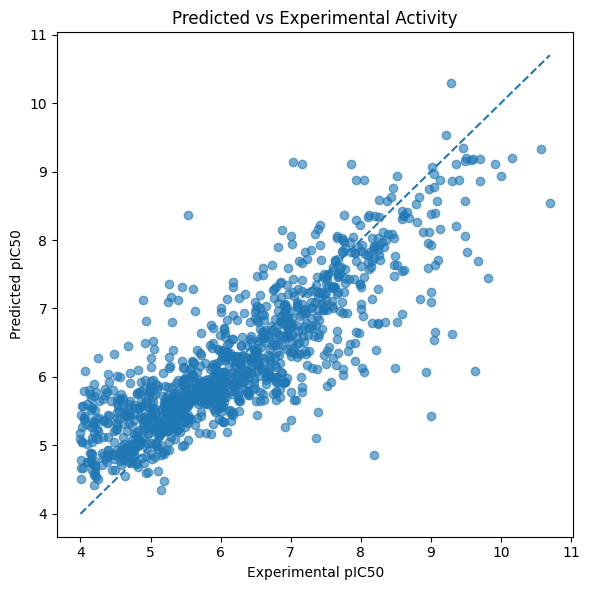

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)

minimum = min(y_test.min(), predictions.min())
maximum = max(y_test.max(), predictions.max())

plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel(f"Experimental {ACTIVITY_COLUMN}")
plt.ylabel(f"Predicted {ACTIVITY_COLUMN}")
plt.title("Predicted vs Experimental Activity")
plt.tight_layout()
plt.show()


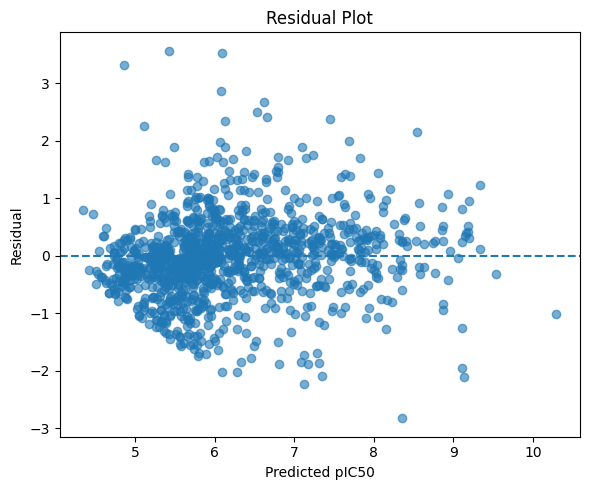

In [ ]:
residuals = y_test - predictions

plt.figure(figsize=(6, 5))
plt.scatter(predictions, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel(f"Predicted {ACTIVITY_COLUMN}")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()


In [ ]:
results_df = final_df.iloc[test_idx].copy()
results_df[f"experimental_{ACTIVITY_COLUMN}"] = y_test
results_df[f"predicted_{ACTIVITY_COLUMN}"] = predictions
results_df["absolute_error"] = np.abs(y_test - predictions)
results_df.to_csv(PREDICTIONS_PATH, index=False)

print(PREDICTIONS_PATH)
display(results_df.sort_values("absolute_error").head(10))
display(results_df.sort_values("absolute_error", ascending=False).head(10))


/content/drive/MyDrive/AChE_QSAR_Resumable/CHEMBL220_IC50_test_predictions.csv


,molecule_chembl_id,canonical_smiles,pIC50,measurement_count,experimental_pIC50,predicted_pIC50,absolute_error
4343,CHEMBL4856140,CCOC(=O)/C(=N\Nc1ccc(C(=O)OCC)cc1)C(=O)C(F)(F)F,5.421361,1,5.421361,5.420992,0.000369
4155,CHEMBL4788008,COc1cc(/C=C/C(=O)N2CCN(c3ccc(Cl)cc3)CC2)ccc1O,4.952725,1,4.952725,4.954352,0.001627
4174,CHEMBL4789794,COc1cc(/C=C/C(=O)NCC(=O)Nc2ccc3ncccc3c2)ccc1O,5.310691,1,5.310691,5.312739,0.002048
2098,CHEMBL337714,CSc1nc(-c2ccc(C(F)(F)F)cc2)nn1C(=O)N(C)C,6.301030,1,6.301030,6.304917,0.003887
2574,CHEMBL376186,COc1ccccc1CN(C)CCCCCCCOc1ccc2c(=O)c3ccccc3oc2c1,5.661544,1,5.661543,5.657639,0.003904
2689,CHEMBL3822890,Cc1ccccc1CN1CCC(C(=O)NCCc2c[nH]c3ccccc23)CC1,5.448550,1,5.448550,5.444184,0.004366
4154,CHEMBL4787855,COc1cc2c(cc1OC)C(=O)/C(=C/c1ccc(N3CC[N+](C)(Cc...,6.318759,1,6.318759,6.313972,0.004787
1756,CHEMBL3215769,Cl.Cl.Cl.Cl.O=C(NCCCCCCCCCNc1c2c(nc3cc(Cl)ccc1...,7.603801,1,7.603801,7.609157,0.005356
4273,CHEMBL4799941,COc1cc(/C=C/C(=O)NCC(=O)Nc2ccc3[nH]ccc3c2)ccc1O,5.241088,2,5.241088,5.235218,0.005870
5406,CHEMBL597821,CN(Cc1ccccc1)Cc1ccc(/C=C2\Cc3ccc(OCCCCN4CCOCC4...,6.050610,1,6.050610,6.057124,0.006514


,molecule_chembl_id,canonical_smiles,pIC50,measurement_count,experimental_pIC50,predicted_pIC50,absolute_error
3855,CHEMBL4647106,COc1ccc([C@H](O)[C@H](N)C(=O)O)cc1OC,9.000000,1,9.000000,5.432105,3.567895
994,CHEMBL1940738,COc1cc2oc(=O)c(OCCCCOc3cc(O)cc(N(C)C)c3)c(C)c2...,9.627088,1,9.627088,6.092400,3.534688
1513,CHEMBL253998,CC(C)=CCc1c(O)cc(O)c2c1O[C@H](c1ccccc1)CC2=O,8.193820,1,8.193820,4.866201,3.327619
1144,CHEMBL2178784,COc1ccc2c3c1O[C@H]1C[C@@H](O)C=C[C@@]31CCN(CCC...,8.935542,1,8.935542,6.076327,2.859215
3123,CHEMBL4109726,CC1=C[C@H]2Cc3nc4cc(Cl)ccc4c(NCCCCCCCCCNC(=O)c...,5.533132,1,5.533133,8.359305,2.826172
4842,CHEMBL5280980,C[n+]1ccc2c3ccccc3n(CCc3ccccc3)c2c1,9.301030,1,9.301030,6.620163,2.680867
2227,CHEMBL345847,CN1CCC(CCN2C(=O)c3ccccc3C2=O)CC1,9.045757,1,9.045757,6.538578,2.507179
5619,CHEMBL6170750,c1ccc2oc(CNCCCCCCCNc3c4c(cc5ccccc35)CCCC4)cc2c1,9.065502,1,9.065501,6.658242,2.407260
4628,CHEMBL5187881,COc1cc2c(cc1OC)C(=O)/C(=C/c1cc[n+](Cc3ccc(F)cc...,9.823909,1,9.823909,7.444943,2.378966
5217,CHEMBL5574923,O=C(CCCCN1CCN(Cc2ccccc2)CC1)Nc1ccc2nc3n(c(=O)c...,8.482804,1,8.482804,6.133548,2.349256


## 6. Additional validation

Test model behavior using alternate splits and evaluate performance on unfamiliar chemical scaffolds.

In [ ]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=FINGERPRINT_RADIUS,
    fpSize=FINGERPRINT_SIZE
)

X_full = []
y_full = []
scaffolds = []

for _, row in final_df.iterrows():
    smiles = row["canonical_smiles"]
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        continue

    fingerprint = generator.GetFingerprintAsNumPy(mol)

    scaffold = MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol,
        includeChirality=False
    )

    if scaffold == "":
        scaffold = Chem.MolToSmiles(mol, canonical=True)

    X_full.append(fingerprint)
    y_full.append(row[ACTIVITY_COLUMN])
    scaffolds.append(scaffold)

X_full = np.asarray(X_full, dtype=np.uint8)
y_full = np.asarray(y_full, dtype=np.float32)

scaffold_groups = {}

for index, scaffold in enumerate(scaffolds):
    scaffold_groups.setdefault(scaffold, []).append(index)

groups = sorted(
    scaffold_groups.values(),
    key=lambda group: len(group),
    reverse=True
)

target_test_size = int(len(X_full) * TEST_SIZE)

scaffold_test_idx = []
scaffold_train_idx = []

for group in groups:
    if len(scaffold_test_idx) + len(group) <= target_test_size:
        scaffold_test_idx.extend(group)
    else:
        scaffold_train_idx.extend(group)

scaffold_train_idx = np.asarray(scaffold_train_idx)
scaffold_test_idx = np.asarray(scaffold_test_idx)

X_scaffold_train = X_full[scaffold_train_idx]
X_scaffold_test = X_full[scaffold_test_idx]
y_scaffold_train = y_full[scaffold_train_idx]
y_scaffold_test = y_full[scaffold_test_idx]

print("Scaffold training compounds:", len(X_scaffold_train))
print("Scaffold testing compounds:", len(X_scaffold_test))
print("Training scaffolds:", len(set(scaffolds[i] for i in scaffold_train_idx)))
print("Testing scaffolds:", len(set(scaffolds[i] for i in scaffold_test_idx)))
print(
    "Shared scaffolds:",
    len(
        set(scaffolds[i] for i in scaffold_train_idx) &
        set(scaffolds[i] for i in scaffold_test_idx)
    )
)

Scaffold training compounds: 4664
Scaffold testing compounds: 1166
Training scaffolds: 2426
Testing scaffolds: 46
Shared scaffolds: 0


In [ ]:
scaffold_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

scaffold_rf.fit(
    X_scaffold_train,
    y_scaffold_train
)

scaffold_predictions = scaffold_rf.predict(X_scaffold_test)

scaffold_r2 = r2_score(
    y_scaffold_test,
    scaffold_predictions
)

scaffold_rmse = np.sqrt(
    mean_squared_error(
        y_scaffold_test,
        scaffold_predictions
    )
)

scaffold_mae = mean_absolute_error(
    y_scaffold_test,
    scaffold_predictions
)

print("Scaffold-split R²:", round(scaffold_r2, 3))
print("Scaffold-split RMSE:", round(scaffold_rmse, 3))
print("Scaffold-split MAE:", round(scaffold_mae, 3))

KeyboardInterrupt: 

In [ ]:
!pip -q install deepchem

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 10.5 MB/s eta 0:00:00


In [ ]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [ ]:
import deepchem as dc
import pandas as pd
import numpy as np

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


In [ ]:
dataset_df = final_df[
    ["canonical_smiles", ACTIVITY_COLUMN]
].rename(
    columns={
        "canonical_smiles": "smiles",
        ACTIVITY_COLUMN: "activity"
    }
)

dataset_df.head()

,smiles,activity
0,CN(CCOCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,6.920819
1,CN1CC[C@@]2(C)c3cc(OC(=O)Nc4ccccc4)ccc3N(C=O)C12,6.107683
2,CN(CCOCCNC(=S)NC(=O)c1ccc2ccccc2c1)Cc1ccccc1,7.000000
3,CN(CCOCCNC(=S)Nc1ccc(OC(F)(F)F)cc1)Cc1ccccc1,6.000000
4,CN(CCOCCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,5.958607


In [ ]:
import deepchem as dc
import numpy as np

conv_featurizer = dc.feat.ConvMolFeaturizer()

conv_graphs = conv_featurizer.featurize(
    dataset_df["smiles"].tolist()
)

conv_dataset = dc.data.NumpyDataset(
    X=conv_graphs,
    y=dataset_df["activity"].to_numpy(dtype=np.float32).reshape(-1, 1)
)

print("ConvMol graphs:", len(conv_graphs))
print(conv_dataset)

Streaming output truncated to the last 5000 lines.
[02:35:22] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:22] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:22] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:22] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:22] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:22] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:22] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:22] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:22] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:22] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:22] DEPRECATION WARNING: please use GetValence(Chem.

ConvMol graphs: 5830
<NumpyDataset X.shape: (5830,), y.shape: (5830, 1), w.shape: (5830, 1), task_names: [0]>


[02:35:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:35:23] DEPRECATIO

## 7. Alternative model comparisons

Compare fingerprint, descriptor, and graph-based approaches before selecting the production model.

In [ ]:
random_train_dataset = conv_dataset.select(train_idx)
random_test_dataset = conv_dataset.select(test_idx)

scaffold_train_dataset = conv_dataset.select(
    scaffold_train_idx
)

scaffold_test_dataset = conv_dataset.select(
    scaffold_test_idx
)

print("Random train:", len(random_train_dataset))
print("Random test:", len(random_test_dataset))
print("Scaffold train:", len(scaffold_train_dataset))
print("Scaffold test:", len(scaffold_test_dataset))

Random train: 4664
Random test: 1166
Scaffold train: 4664
Scaffold test: 1166


In [ ]:
random_transformer = dc.trans.NormalizationTransformer(
    transform_y=True,
    dataset=random_train_dataset
)

random_train_transformed = random_transformer.transform(
    random_train_dataset
)

random_test_transformed = random_transformer.transform(
    random_test_dataset
)

scaffold_transformer = dc.trans.NormalizationTransformer(
    transform_y=True,
    dataset=scaffold_train_dataset
)

scaffold_train_transformed = scaffold_transformer.transform(
    scaffold_train_dataset
)

scaffold_test_transformed = scaffold_transformer.transform(
    scaffold_test_dataset
)

print("Normalization complete")

Normalization complete


In [ ]:
import tensorflow as tf
import tf_keras
import deepchem as dc

print("TensorFlow:", tf.__version__)
print("Legacy Keras:", tf_keras.__version__)
print("DeepChem:", dc.__version__)
print("Using:", tf.keras)

TensorFlow: 2.20.0
Legacy Keras: 2.20.0
DeepChem: 2.5.0
Using: <module 'tensorflow.keras' from '/usr/local/lib/python3.12/dist-packages/tf_keras/api/_v2/keras/__init__.py'>


In [ ]:
import os
import shutil

gcn_random_dir = "/content/graphconv_random_legacy"

if os.path.exists(gcn_random_dir):
    shutil.rmtree(gcn_random_dir)

graphconv_random = dc.models.GraphConvModel(
    n_tasks=1,
    graph_conv_layers=[64, 64],
    dense_layer_size=128,
    dropout=0.2,
    mode="regression",
    batch_size=64,
    learning_rate=0.001,
    model_dir=gcn_random_dir
)

print("GraphConvModel created successfully")

GraphConvModel created successfully


In [ ]:
from google.colab import drive
import os
import deepchem as dc

drive.mount("/content/drive")

gcn_random_dir = (
    "/content/drive/MyDrive/AChE_QSAR/"
    "graphconv_random_legacy"
)

os.makedirs(gcn_random_dir, exist_ok=True)

graphconv_random = dc.models.GraphConvModel(
    n_tasks=1,
    graph_conv_layers=[64, 64],
    dense_layer_size=128,
    dropout=0.2,
    mode="regression",
    batch_size=64,
    learning_rate=0.001,
    model_dir=gcn_random_dir
)

print("Drive-backed GraphConvModel created")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive-backed GraphConvModel created


In [ ]:
training_loss = graphconv_random.fit(
    random_train_transformed,
    nb_epoch=50,
    checkpoint_interval=250,
    max_checkpoints_to_keep=3
)

print("Final training loss:", training_loss)
print("Checkpoints:", graphconv_random.get_checkpoints())

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
import numpy as np

random_predictions = graphconv_random.predict(
    random_test_transformed,
    transformers=[random_transformer]
).reshape(-1)

random_true = random_test_dataset.y.reshape(-1)

graphconv_random_r2 = r2_score(
    random_true,
    random_predictions
)

graphconv_random_rmse = np.sqrt(
    mean_squared_error(
        random_true,
        random_predictions
    )
)

graphconv_random_mae = mean_absolute_error(
    random_true,
    random_predictions
)

print(
    "GraphConv random-split R²:",
    round(graphconv_random_r2, 3)
)

print(
    "GraphConv random-split RMSE:",
    round(graphconv_random_rmse, 3)
)

print(
    "GraphConv random-split MAE:",
    round(graphconv_random_mae, 3)
)

GraphConv random-split R²: 0.524
GraphConv random-split RMSE: 0.905
GraphConv random-split MAE: 0.694


In [ ]:
import os
import shutil

gcn_scaffold_dir = (
    "/content/drive/MyDrive/AChE_QSAR/"
    "graphconv_scaffold_legacy"
)

if os.path.exists(gcn_scaffold_dir):
    shutil.rmtree(gcn_scaffold_dir)

os.makedirs(gcn_scaffold_dir, exist_ok=True)

graphconv_scaffold = dc.models.GraphConvModel(
    n_tasks=1,
    graph_conv_layers=[64, 64],
    dense_layer_size=128,
    dropout=0.2,
    mode="regression",
    batch_size=64,
    learning_rate=0.001,
    model_dir=gcn_scaffold_dir
)

print("Fresh scaffold GraphConvModel created")

Fresh scaffold GraphConvModel created


In [ ]:
scaffold_training_loss = graphconv_scaffold.fit(
    scaffold_train_transformed,
    nb_epoch=50,
    checkpoint_interval=250,
    max_checkpoints_to_keep=3
)

print("Final training loss:", scaffold_training_loss)
print("Checkpoints:", graphconv_scaffold.get_checkpoints())

Final training loss: 0.39084457397460937
Checkpoints: ['/content/drive/MyDrive/AChE_QSAR/graphconv_scaffold_legacy/ckpt-13', '/content/drive/MyDrive/AChE_QSAR/graphconv_scaffold_legacy/ckpt-14', '/content/drive/MyDrive/AChE_QSAR/graphconv_scaffold_legacy/ckpt-15']


In [ ]:
scaffold_graphconv_predictions = graphconv_scaffold.predict(
    scaffold_test_transformed,
    transformers=[scaffold_transformer]
).reshape(-1)

scaffold_graphconv_true = scaffold_test_dataset.y.reshape(-1)

graphconv_scaffold_r2 = r2_score(
    scaffold_graphconv_true,
    scaffold_graphconv_predictions
)

graphconv_scaffold_rmse = np.sqrt(
    mean_squared_error(
        scaffold_graphconv_true,
        scaffold_graphconv_predictions
    )
)

graphconv_scaffold_mae = mean_absolute_error(
    scaffold_graphconv_true,
    scaffold_graphconv_predictions
)

print(
    "GraphConv scaffold-split R²:",
    round(graphconv_scaffold_r2, 3)
)

print(
    "GraphConv scaffold-split RMSE:",
    round(graphconv_scaffold_rmse, 3)
)

print(
    "GraphConv scaffold-split MAE:",
    round(graphconv_scaffold_mae, 3)
)

GraphConv scaffold-split R²: 0.291
GraphConv scaffold-split RMSE: 1.03
GraphConv scaffold-split MAE: 0.794


In [ ]:
results = {
    "Random Forest — Random": {
        "R2": 0.703,
        "RMSE": 0.715,
        "MAE": 0.506
    },
    "Random Forest — Scaffold": {
        "R2": 0.321,
        "RMSE": 1.008,
        "MAE": 0.755
    },
    "GraphConv — Random": {
        "R2": 0.524,
        "RMSE": 0.905,
        "MAE": 0.694
    },
    "GraphConv — Scaffold": {
        "R2": 0.291,
        "RMSE": 1.030,
        "MAE": 0.794
    }
}

results

{'Random Forest — Random': {'R2': 0.703, 'RMSE': 0.715, 'MAE': 0.506},
 'Random Forest — Scaffold': {'R2': 0.321, 'RMSE': 1.008, 'MAE': 0.755},
 'GraphConv — Random': {'R2': 0.524, 'RMSE': 0.905, 'MAE': 0.694},
 'GraphConv — Scaffold': {'R2': 0.291, 'RMSE': 1.03, 'MAE': 0.794}}

In [ ]:
import json
import os

results_path = (
    "/content/drive/MyDrive/AChE_QSAR/"
    "model_results.json"
)

os.makedirs(os.path.dirname(results_path), exist_ok=True)

with open(results_path, "w") as file:
    json.dump(results, file, indent=2)

print("Results saved to:", results_path)

Results saved to: /content/drive/MyDrive/AChE_QSAR/model_results.json


In [ ]:
!pip -q install torch_geometric

In [ ]:
import torch
import torch_geometric

from torch_geometric.nn import (
    GINEConv,
    global_mean_pool
)

print("PyTorch:", torch.__version__)
print("PyTorch Geometric:", torch_geometric.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
PyTorch Geometric: 2.8.0.post1
GPU available: True


In [ ]:
import torch
import torch_geometric

print("PyTorch:", torch.__version__)
print("PyTorch Geometric:", torch_geometric.__version__)
print("CUDA version:", torch.version.cuda)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
PyTorch Geometric: 2.8.0.post1
CUDA version: 12.8
GPU available: True
GPU: Tesla T4


In [ ]:
import torch
import numpy as np

required = [
    "dataset_df",
    "train_idx",
    "test_idx",
    "scaffold_train_idx",
    "scaffold_test_idx"
]

missing = [name for name in required if name not in globals()]

if missing:
    raise NameError("Missing: " + ", ".join(missing))

print("Dataset:", dataset_df.shape)
print("Random:", len(train_idx), len(test_idx))
print("Scaffold:", len(scaffold_train_idx), len(scaffold_test_idx))
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Dataset: (5830, 2)
Random: 4664 1166
Scaffold: 4664 1166
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
import os
import numpy as np

core_dir = "/content/drive/MyDrive/AChE_QSAR/core_data"
os.makedirs(core_dir, exist_ok=True)

dataset_df.to_csv(
    os.path.join(core_dir, "ache_dataset.csv"),
    index=False
)

np.savez(
    os.path.join(core_dir, "split_indices.npz"),
    train_idx=np.asarray(train_idx, dtype=np.int64),
    test_idx=np.asarray(test_idx, dtype=np.int64),
    scaffold_train_idx=np.asarray(
        scaffold_train_idx,
        dtype=np.int64
    ),
    scaffold_test_idx=np.asarray(
        scaffold_test_idx,
        dtype=np.int64
    )
)

print("Core dataset and indices saved")

Core dataset and indices saved


In [ ]:
import torch
from rdkit import Chem
from torch_geometric.data import Data

HYBRIDIZATIONS = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2
]

CHIRAL_TAGS = [
    Chem.rdchem.ChiralType.CHI_UNSPECIFIED,
    Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CW,
    Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CCW,
    Chem.rdchem.ChiralType.CHI_OTHER
]

BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC
]

BOND_STEREOS = [
    Chem.rdchem.BondStereo.STEREONONE,
    Chem.rdchem.BondStereo.STEREOANY,
    Chem.rdchem.BondStereo.STEREOZ,
    Chem.rdchem.BondStereo.STEREOE,
    Chem.rdchem.BondStereo.STEREOCIS,
    Chem.rdchem.BondStereo.STEREOTRANS
]


def one_hot(value, choices):
    return [float(value == choice) for choice in choices]


def atom_features(atom):
    return [
        atom.GetAtomicNum() / 100.0,
        atom.GetDegree() / 6.0,
        atom.GetFormalCharge() / 4.0,
        atom.GetTotalNumHs() / 4.0,
        atom.GetTotalValence() / 8.0,
        float(atom.GetIsAromatic()),
        float(atom.IsInRing())
    ] + one_hot(
        atom.GetHybridization(),
        HYBRIDIZATIONS
    ) + one_hot(
        atom.GetChiralTag(),
        CHIRAL_TAGS
    )


def bond_features(bond):
    return (
        one_hot(bond.GetBondType(), BOND_TYPES)
        + [
            float(bond.GetIsConjugated()),
            float(bond.IsInRing())
        ]
        + one_hot(bond.GetStereo(), BOND_STEREOS)
    )


def smiles_to_graph(smiles, activity, original_index):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    x = torch.tensor(
        [atom_features(atom) for atom in mol.GetAtoms()],
        dtype=torch.float
    )

    edge_pairs = []
    edge_features = []

    for bond in mol.GetBonds():
        begin = bond.GetBeginAtomIdx()
        end = bond.GetEndAtomIdx()
        features = bond_features(bond)

        edge_pairs.extend([
            [begin, end],
            [end, begin]
        ])

        edge_features.extend([
            features,
            features
        ])

    edge_feature_dim = len(BOND_TYPES) + 2 + len(BOND_STEREOS)

    if edge_pairs:
        edge_index = torch.tensor(
            edge_pairs,
            dtype=torch.long
        ).t().contiguous()

        edge_attr = torch.tensor(
            edge_features,
            dtype=torch.float
        )
    else:
        edge_index = torch.empty(
            (2, 0),
            dtype=torch.long
        )

        edge_attr = torch.empty(
            (0, edge_feature_dim),
            dtype=torch.float
        )

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=torch.tensor([activity], dtype=torch.float),
        original_index=torch.tensor(
            [original_index],
            dtype=torch.long
        )
    )


pyg_graphs = []
failed_indices = []

for index, row in dataset_df.iterrows():
    graph = smiles_to_graph(
        row["smiles"],
        float(row["activity"]),
        index
    )

    if graph is None:
        failed_indices.append(index)
    else:
        pyg_graphs.append(graph)

print("Graphs created:", len(pyg_graphs))
print("Failed molecules:", len(failed_indices))
print("Node feature count:", pyg_graphs[0].num_node_features)
print("Bond feature count:", pyg_graphs[0].num_edge_features)
print(pyg_graphs[0])

Graphs created: 5830
Failed molecules: 0
Node feature count: 16
Bond feature count: 12
Data(x=[26, 16], edge_index=[2, 54], edge_attr=[54, 12], y=[1], original_index=[1])


In [ ]:
graph_path = (
    "/content/drive/MyDrive/AChE_QSAR/core_data/"
    "gine_graphs.pt"
)

torch.save(pyg_graphs, graph_path)

print("GINE graphs saved to:", graph_path)

GINE graphs saved to: /content/drive/MyDrive/AChE_QSAR/core_data/gine_graphs.pt


In [ ]:
import os
import random
import numpy as np
import torch

from torch_geometric.loader import DataLoader

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

graph_by_index = {
    int(graph.original_index.item()): graph
    for graph in pyg_graphs
}

random_train_indices = np.asarray(
    train_idx,
    dtype=np.int64
)

random_test_indices = np.asarray(
    test_idx,
    dtype=np.int64
)

missing_indices = [
    int(index)
    for index in np.concatenate([
        random_train_indices,
        random_test_indices
    ])
    if int(index) not in graph_by_index
]

if missing_indices:
    raise ValueError(
        f"Missing {len(missing_indices)} graphs."
    )

random_train_values = np.asarray([
    graph_by_index[int(index)].y.item()
    for index in random_train_indices
])

random_y_mean = float(random_train_values.mean())
random_y_std = float(random_train_values.std())

if random_y_std == 0:
    raise ValueError("Training-label standard deviation is zero.")

random_train_graphs = []

for index in random_train_indices:
    graph = graph_by_index[int(index)].clone()
    graph.y = (
        graph.y - random_y_mean
    ) / random_y_std

    random_train_graphs.append(graph)

random_test_graphs = [
    graph_by_index[int(index)].clone()
    for index in random_test_indices
]

random_train_loader = DataLoader(
    random_train_graphs,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

random_test_loader = DataLoader(
    random_test_graphs,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Device:", device)
print("Random training graphs:", len(random_train_graphs))
print("Random testing graphs:", len(random_test_graphs))
print("Training activity mean:", round(random_y_mean, 4))
print("Training activity SD:", round(random_y_std, 4))

Device: cuda
Random training graphs: 4664
Random testing graphs: 1166
Training activity mean: 6.1449
Training activity SD: 1.2817


## 8. Production model

Train the selected random forest on the complete curated AChE dataset.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    GINEConv,
    global_mean_pool,
    global_max_pool
)


class GINERegressor(nn.Module):
    def __init__(
        self,
        node_dim,
        edge_dim,
        hidden_dim=128,
        num_layers=3,
        dropout=0.2
    ):
        super().__init__()

        self.dropout = dropout

        self.node_encoder = nn.Linear(
            node_dim,
            hidden_dim
        )

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )

            self.convs.append(
                GINEConv(
                    nn=mlp,
                    train_eps=True,
                    edge_dim=edge_dim
                )
            )

            self.norms.append(
                nn.BatchNorm1d(hidden_dim)
            )

        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x = self.node_encoder(data.x)
        x = F.relu(x)

        for conv, norm in zip(
            self.convs,
            self.norms
        ):
            residual = x

            x = conv(
                x,
                data.edge_index,
                data.edge_attr
            )

            x = norm(x)
            x = F.relu(x + residual)
            x = F.dropout(
                x,
                p=self.dropout,
                training=self.training
            )

        mean_pool = global_mean_pool(
            x,
            data.batch
        )

        max_pool = global_max_pool(
            x,
            data.batch
        )

        graph_embedding = torch.cat(
            [mean_pool, max_pool],
            dim=1
        )

        return self.predictor(
            graph_embedding
        ).view(-1)


node_dim = pyg_graphs[0].num_node_features
edge_dim = pyg_graphs[0].num_edge_features

gine_random = GINERegressor(
    node_dim=node_dim,
    edge_dim=edge_dim,
    hidden_dim=128,
    num_layers=3,
    dropout=0.2
).to(device)

parameter_count = sum(
    parameter.numel()
    for parameter in gine_random.parameters()
    if parameter.requires_grad
)

print("Node features:", node_dim)
print("Bond features:", edge_dim)
print("Trainable parameters:", parameter_count)
print(gine_random)

Node features: 16
Bond features: 12
Trainable parameters: 140036
GINERegressor(
  (node_encoder): Linear(in_features=16, out_features=128, bias=True)
  (convs): ModuleList(
    (0-2): 3 x GINEConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    ))
  )
  (norms): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (predictor): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [ ]:
import shutil

checkpoint_dir = (
    "/content/drive/MyDrive/AChE_QSAR/"
    "gine_random"
)

os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(
    checkpoint_dir,
    "resume_checkpoint.pt"
)

local_checkpoint_path = (
    "/content/gine_random_checkpoint.pt"
)

optimizer = torch.optim.AdamW(
    gine_random.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=20,
    gamma=0.5
)

criterion = nn.MSELoss()

start_epoch = 0
training_history = []

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    gine_random.load_state_dict(
        checkpoint["model_state"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state"]
    )

    scheduler.load_state_dict(
        checkpoint["scheduler_state"]
    )

    start_epoch = checkpoint["epoch"] + 1

    training_history = checkpoint.get(
        "training_history",
        []
    )

    print(
        "Resuming from epoch:",
        start_epoch + 1
    )

EPOCHS = 50

for epoch in range(start_epoch, EPOCHS):
    gine_random.train()

    total_loss = 0.0
    total_graphs = 0

    for batch in random_train_loader:
        batch = batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        predictions = gine_random(batch)

        loss = criterion(
            predictions,
            batch.y.view(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            gine_random.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        total_loss += (
            loss.item() * batch.num_graphs
        )

        total_graphs += batch.num_graphs

    scheduler.step()

    epoch_loss = total_loss / total_graphs
    training_history.append(epoch_loss)

    checkpoint = {
        "epoch": epoch,
        "model_state": gine_random.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "training_history": training_history,
        "y_mean": random_y_mean,
        "y_std": random_y_std
    }

    torch.save(
        checkpoint,
        local_checkpoint_path
    )

    shutil.copy2(
        local_checkpoint_path,
        checkpoint_path
    )

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Loss: {epoch_loss:.4f} | "
        f"LR: {current_lr:.6f}"
    )

print("Random-split GINE training complete")

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 01/50 | Loss: 0.9751 | LR: 0.001000
Epoch 02/50 | Loss: 0.8296 | LR: 0.001000
Epoch 03/50 | Loss: 0.7991 | LR: 0.001000
Epoch 04/50 | Loss: 0.7748 | LR: 0.001000
Epoch 05/50 | Loss: 0.7421 | LR: 0.001000
Epoch 06/50 | Loss: 0.7329 | LR: 0.001000
Epoch 07/50 | Loss: 0.7110 | LR: 0.001000
Epoch 08/50 | Loss: 0.7135 | LR: 0.001000
Epoch 09/50 | Loss: 0.6681 | LR: 0.001000
Epoch 10/50 | Loss: 0.6767 | LR: 0.001000
Epoch 11/50 | Loss: 0.6423 | LR: 0.001000
Epoch 12/50 | Loss: 0.6514 | LR: 0.001000
Epoch 13/50 | Loss: 0.6301 | LR: 0.001000
Epoch 14/50 | Loss: 0.6082 | LR: 0.001000
Epoch 15/50 | Loss: 0.6055 | LR: 0.001000
Epoch 16/50 | Loss: 0.5879 | LR: 0.001000
Epoch 17/50 | Loss: 0.5676 | LR: 0.001000
Epoch 18/50 | Loss: 0.5756 | LR: 0.001000
Epoch 19/50 | Loss: 0.5893 | LR: 0.001000
Epoch 20/50 | Loss: 0.5556 | LR: 0.000500
Epoch 21/50 | Loss: 0.5145 | LR: 0.000500
Epoch 22/50 | Loss: 0.4907 | LR: 0.000500
Epoch 23/50 | Loss: 0.4939 | LR: 0.000500
Epoch 24/50 | Loss: 0.4837 | LR: 0

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

gine_random.eval()

gine_random_predictions = []
gine_random_true = []

with torch.no_grad():
    for batch in random_test_loader:
        batch = batch.to(
            device,
            non_blocking=True
        )

        normalized_predictions = gine_random(
            batch
        )

        activity_predictions = (
            normalized_predictions * random_y_std
            + random_y_mean
        )

        gine_random_predictions.extend(
            activity_predictions.cpu().numpy()
        )

        gine_random_true.extend(
            batch.y.view(-1).cpu().numpy()
        )

gine_random_predictions = np.asarray(
    gine_random_predictions
)

gine_random_true = np.asarray(
    gine_random_true
)

gine_random_r2 = r2_score(
    gine_random_true,
    gine_random_predictions
)

gine_random_rmse = np.sqrt(
    mean_squared_error(
        gine_random_true,
        gine_random_predictions
    )
)

gine_random_mae = mean_absolute_error(
    gine_random_true,
    gine_random_predictions
)

print(
    "GINE random-split R²:",
    round(gine_random_r2, 3)
)

print(
    "GINE random-split RMSE:",
    round(gine_random_rmse, 3)
)

print(
    "GINE random-split MAE:",
    round(gine_random_mae, 3)
)

GINE random-split R²: 0.425
GINE random-split RMSE: 0.994
GINE random-split MAE: 0.77


In [ ]:
import os
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import Descriptors

descriptor_rows = []
failed_indices = []

for index, smiles in enumerate(dataset_df["smiles"]):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        failed_indices.append(index)
        descriptor_rows.append({})
        continue

    values = Descriptors.CalcMolDescriptors(
        mol,
        missingVal=np.nan,
        silent=True
    )

    descriptor_rows.append(values)

    if (index + 1) % 500 == 0:
        print(f"Processed {index + 1}/{len(dataset_df)} molecules")

descriptor_df = pd.DataFrame(descriptor_rows)

descriptor_df = descriptor_df.replace(
    [np.inf, -np.inf],
    np.nan
)

all_missing_columns = descriptor_df.columns[
    descriptor_df.isna().all()
].tolist()

descriptor_df = descriptor_df.drop(
    columns=all_missing_columns
)

constant_columns = [
    column
    for column in descriptor_df.columns
    if descriptor_df[column].nunique(dropna=True) <= 1
]

descriptor_df = descriptor_df.drop(
    columns=constant_columns
)

descriptor_df.insert(
    0,
    "activity",
    dataset_df["activity"].to_numpy()
)

descriptor_df.insert(
    0,
    "smiles",
    dataset_df["smiles"].to_numpy()
)

descriptor_path = (
    "/content/drive/MyDrive/AChE_QSAR/core_data/"
    "rdkit_descriptors.csv"
)

os.makedirs(
    os.path.dirname(descriptor_path),
    exist_ok=True
)

descriptor_df.to_csv(
    descriptor_path,
    index=False
)

print()
print("Descriptor table:", descriptor_df.shape)
print("Failed molecules:", len(failed_indices))
print("All-missing columns removed:", len(all_missing_columns))
print("Constant columns removed:", len(constant_columns))
print("Saved to:", descriptor_path)

descriptor_df.head()

Processed 500/5830 molecules
Processed 1000/5830 molecules
Processed 1500/5830 molecules
Processed 2000/5830 molecules
Processed 2500/5830 molecules
Processed 3000/5830 molecules
Processed 3500/5830 molecules
Processed 4000/5830 molecules
Processed 4500/5830 molecules
Processed 5000/5830 molecules
Processed 5500/5830 molecules

Descriptor table: (5830, 209)
Failed molecules: 0
All-missing columns removed: 0
Constant columns removed: 10
Saved to: /content/drive/MyDrive/AChE_QSAR/core_data/rdkit_descriptors.csv


,smiles,activity,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,CN(CCOCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,6.920819,11.939886,11.939886,0.216153,-0.216153,0.523804,10.538462,371.506,346.306,...,0,0,0,0,0,0,0,0,0,0
1,CN1CC[C@@]2(C)c3cc(OC(=O)Nc4ccccc4)ccc3N(C=O)C12,6.107683,12.154022,12.154022,0.003144,-0.535525,0.862927,24.076923,351.406,330.238,...,0,0,0,0,0,0,0,0,0,0
2,CN(CCOCCNC(=S)NC(=O)c1ccc2ccccc2c1)Cc1ccccc1,7.000000,12.383574,12.383574,0.220641,-0.220641,0.408508,10.866667,421.566,394.350,...,0,0,0,0,0,0,0,0,0,0
3,CN(CCOCCNC(=S)Nc1ccc(OC(F)(F)F)cc1)Cc1ccccc1,6.000000,12.139000,12.139000,0.284667,-4.706195,0.441236,11.344828,427.492,403.300,...,0,0,0,0,0,0,0,0,0,0
4,CN(CCOCCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,5.958607,11.955977,11.955977,0.202960,-0.202960,0.486562,10.592593,385.533,358.317,...,0,0,0,0,0,0,0,0,0,0


## 9. External compound screening

Standardize the external library, remove training-set overlaps, predict activity, and apply applicability filters.

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer

descriptor_columns = [
    column
    for column in descriptor_df.columns
    if column not in ["smiles", "activity"]
]

X_descriptors = descriptor_df[
    descriptor_columns
].to_numpy(dtype=np.float32)

y_descriptors = descriptor_df[
    "activity"
].to_numpy(dtype=np.float32)

random_descriptor_imputer = SimpleImputer(
    strategy="median"
)

X_descriptor_random_train = (
    random_descriptor_imputer.fit_transform(
        X_descriptors[train_idx]
    )
)

X_descriptor_random_test = (
    random_descriptor_imputer.transform(
        X_descriptors[test_idx]
    )
)

scaffold_descriptor_imputer = SimpleImputer(
    strategy="median"
)

X_descriptor_scaffold_train = (
    scaffold_descriptor_imputer.fit_transform(
        X_descriptors[scaffold_train_idx]
    )
)

X_descriptor_scaffold_test = (
    scaffold_descriptor_imputer.transform(
        X_descriptors[scaffold_test_idx]
    )
)

y_descriptor_random_train = y_descriptors[train_idx]
y_descriptor_random_test = y_descriptors[test_idx]

y_descriptor_scaffold_train = y_descriptors[
    scaffold_train_idx
]

y_descriptor_scaffold_test = y_descriptors[
    scaffold_test_idx
]

print("Descriptor features:", len(descriptor_columns))
print(
    "Random:",
    X_descriptor_random_train.shape,
    X_descriptor_random_test.shape
)
print(
    "Scaffold:",
    X_descriptor_scaffold_train.shape,
    X_descriptor_scaffold_test.shape
)

Descriptor features: 207
Random: (4664, 207) (1166, 207)
Scaffold: (4664, 207) (1166, 207)


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

xgb_parameters = {
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "random_state": RANDOM_SEED,
    "n_jobs": -1
}

descriptor_xgb_random = XGBRegressor(
    **xgb_parameters
)

descriptor_xgb_random.fit(
    X_descriptor_random_train,
    y_descriptor_random_train
)

descriptor_random_predictions = (
    descriptor_xgb_random.predict(
        X_descriptor_random_test
    )
)

descriptor_random_r2 = r2_score(
    y_descriptor_random_test,
    descriptor_random_predictions
)

descriptor_random_rmse = np.sqrt(
    mean_squared_error(
        y_descriptor_random_test,
        descriptor_random_predictions
    )
)

descriptor_random_mae = mean_absolute_error(
    y_descriptor_random_test,
    descriptor_random_predictions
)

descriptor_xgb_scaffold = XGBRegressor(
    **xgb_parameters
)

descriptor_xgb_scaffold.fit(
    X_descriptor_scaffold_train,
    y_descriptor_scaffold_train
)

descriptor_scaffold_predictions = (
    descriptor_xgb_scaffold.predict(
        X_descriptor_scaffold_test
    )
)

descriptor_scaffold_r2 = r2_score(
    y_descriptor_scaffold_test,
    descriptor_scaffold_predictions
)

descriptor_scaffold_rmse = np.sqrt(
    mean_squared_error(
        y_descriptor_scaffold_test,
        descriptor_scaffold_predictions
    )
)

descriptor_scaffold_mae = mean_absolute_error(
    y_descriptor_scaffold_test,
    descriptor_scaffold_predictions
)

print(
    "Descriptor XGBoost random-split R²:",
    round(descriptor_random_r2, 3)
)
print(
    "Descriptor XGBoost random-split RMSE:",
    round(descriptor_random_rmse, 3)
)
print(
    "Descriptor XGBoost random-split MAE:",
    round(descriptor_random_mae, 3)
)

print()

print(
    "Descriptor XGBoost scaffold-split R²:",
    round(descriptor_scaffold_r2, 3)
)
print(
    "Descriptor XGBoost scaffold-split RMSE:",
    round(descriptor_scaffold_rmse, 3)
)
print(
    "Descriptor XGBoost scaffold-split MAE:",
    round(descriptor_scaffold_mae, 3)
)

Descriptor XGBoost random-split R²: 0.691
Descriptor XGBoost random-split RMSE: 0.729
Descriptor XGBoost random-split MAE: 0.521

Descriptor XGBoost scaffold-split R²: 0.284
Descriptor XGBoost scaffold-split RMSE: 1.035
Descriptor XGBoost scaffold-split MAE: 0.787


In [ ]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

SEED = globals().get("RANDOM_SEED", 42)

CHEMPROP_INPUT_DIR = "/content/drive/MyDrive/AChE_QSAR/chemprop_inputs"
RANDOM_DIR = os.path.join(CHEMPROP_INPUT_DIR, "random_split")
SCAFFOLD_DIR = os.path.join(CHEMPROP_INPUT_DIR, "scaffold_split")

os.makedirs(RANDOM_DIR, exist_ok=True)
os.makedirs(SCAFFOLD_DIR, exist_ok=True)

df = dataset_df.reset_index(drop=True).copy()

if not {"smiles", "activity"}.issubset(df.columns):
    raise ValueError("dataset_df must contain smiles and activity columns.")

df["row_id"] = np.arange(len(df))

random_train_pool = np.asarray(train_idx, dtype=int)
random_test = np.asarray(test_idx, dtype=int)
scaffold_train_pool = np.asarray(scaffold_train_idx, dtype=int)
scaffold_test = np.asarray(scaffold_test_idx, dtype=int)

random_train, random_val = train_test_split(
    random_train_pool,
    test_size=0.125,
    random_state=SEED,
    shuffle=True
)

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")

    return MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol,
        includeChirality=False
    )

all_scaffolds = np.array([
    get_scaffold(smiles)
    for smiles in df["smiles"]
])

training_scaffold_groups = all_scaffolds[scaffold_train_pool]
target_val_size = round(len(scaffold_train_pool) * 0.125)

best_train_positions = None
best_val_positions = None
best_difference = float("inf")

for attempt_seed in range(SEED, SEED + 250):
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.125,
        random_state=attempt_seed
    )

    train_positions, val_positions = next(
        splitter.split(
            scaffold_train_pool,
            groups=training_scaffold_groups
        )
    )

    difference = abs(len(val_positions) - target_val_size)

    if difference < best_difference:
        best_difference = difference
        best_train_positions = train_positions
        best_val_positions = val_positions

    if difference == 0:
        break

scaffold_train = scaffold_train_pool[best_train_positions]
scaffold_val = scaffold_train_pool[best_val_positions]

def verify_index_separation(train_ids, val_ids, test_ids):
    train_set = set(train_ids)
    val_set = set(val_ids)
    test_set = set(test_ids)

    overlaps = {
        "train_validation": len(train_set & val_set),
        "train_test": len(train_set & test_set),
        "validation_test": len(val_set & test_set)
    }

    if any(overlaps.values()):
        raise ValueError(f"Index leakage detected: {overlaps}")

    return overlaps

random_overlaps = verify_index_separation(
    random_train,
    random_val,
    random_test
)

scaffold_overlaps = verify_index_separation(
    scaffold_train,
    scaffold_val,
    scaffold_test
)

train_scaffolds = set(all_scaffolds[scaffold_train])
val_scaffolds = set(all_scaffolds[scaffold_val])
test_scaffolds = set(all_scaffolds[scaffold_test])

shared_scaffolds = {
    "train_validation": len(train_scaffolds & val_scaffolds),
    "train_test": len(train_scaffolds & test_scaffolds),
    "validation_test": len(val_scaffolds & test_scaffolds)
}

if any(shared_scaffolds.values()):
    raise ValueError(
        f"Scaffold leakage detected: {shared_scaffolds}"
    )

def save_subset(indices, path):
    subset = (
        df.iloc[np.asarray(indices)][
            ["row_id", "smiles", "activity"]
        ]
        .reset_index(drop=True)
    )

    subset.to_csv(path, index=False)
    return subset

random_train_df = save_subset(
    random_train,
    os.path.join(RANDOM_DIR, "train.csv")
)

random_val_df = save_subset(
    random_val,
    os.path.join(RANDOM_DIR, "validation.csv")
)

random_test_df = save_subset(
    random_test,
    os.path.join(RANDOM_DIR, "test.csv")
)

scaffold_train_df = save_subset(
    scaffold_train,
    os.path.join(SCAFFOLD_DIR, "train.csv")
)

scaffold_val_df = save_subset(
    scaffold_val,
    os.path.join(SCAFFOLD_DIR, "validation.csv")
)

scaffold_test_df = save_subset(
    scaffold_test,
    os.path.join(SCAFFOLD_DIR, "test.csv")
)

np.savez(
    os.path.join(
        CHEMPROP_INPUT_DIR,
        "chemprop_split_indices.npz"
    ),
    random_train=random_train,
    random_val=random_val,
    random_test=random_test,
    scaffold_train=scaffold_train,
    scaffold_val=scaffold_val,
    scaffold_test=scaffold_test
)

print("Random split")
print("Train:", random_train_df.shape)
print("Validation:", random_val_df.shape)
print("Test:", random_test_df.shape)
print("Index overlaps:", random_overlaps)

print("\nScaffold split")
print("Train:", scaffold_train_df.shape)
print("Validation:", scaffold_val_df.shape)
print("Test:", scaffold_test_df.shape)
print("Index overlaps:", scaffold_overlaps)
print("Shared scaffolds:", shared_scaffolds)

print("\nSaved to:", CHEMPROP_INPUT_DIR)

Random split
Train: (4081, 3)
Validation: (583, 3)
Test: (1166, 3)
Index overlaps: {'train_validation': 0, 'train_test': 0, 'validation_test': 0}

Scaffold split
Train: (4081, 3)
Validation: (583, 3)
Test: (1166, 3)
Index overlaps: {'train_validation': 0, 'train_test': 0, 'validation_test': 0}
Shared scaffolds: {'train_validation': 0, 'train_test': 0, 'validation_test': 0}

Saved to: /content/drive/MyDrive/AChE_QSAR/chemprop_inputs


In [ ]:
%pip install -q chemprop==2.3.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.8/151.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.1/328.1 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 68.7 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import subprocess

RANDOM_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/chemprop_inputs/random_split"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/chemprop_outputs/random_split_v1"
)

OUTPUT_DIR.parent.mkdir(parents=True, exist_ok=True)

command = [
    "chemprop",
    "train",
    "--data-path",
    str(RANDOM_DIR / "train.csv"),
    str(RANDOM_DIR / "validation.csv"),
    str(RANDOM_DIR / "test.csv"),
    "--task-type",
    "regression",
    "--smiles-columns",
    "smiles",
    "--target-columns",
    "activity",
    "--output-dir",
    str(OUTPUT_DIR),
    "--accelerator",
    "gpu",
    "--devices",
    "1",
    "--batch-size",
    "64",
    "--epochs",
    "50",
    "--patience",
    "10",
    "--metrics",
    "rmse",
    "mae",
    "r2",
    "--pytorch-seed",
    "42"
]

subprocess.run(command, check=True)

CompletedProcess(args=['chemprop', 'train', '--data-path', '/content/drive/MyDrive/AChE_QSAR/chemprop_inputs/random_split/train.csv', '/content/drive/MyDrive/AChE_QSAR/chemprop_inputs/random_split/validation.csv', '/content/drive/MyDrive/AChE_QSAR/chemprop_inputs/random_split/test.csv', '--task-type', 'regression', '--smiles-columns', 'smiles', '--target-columns', 'activity', '--output-dir', '/content/drive/MyDrive/AChE_QSAR/chemprop_outputs/random_split_v1', '--accelerator', 'gpu', '--devices', '1', '--batch-size', '64', '--epochs', '50', '--patience', '10', '--metrics', 'rmse', 'mae', 'r2', '--pytorch-seed', '42'], returncode=0)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/chemprop_outputs/random_split_v1"
)

TEST_PATH = Path(
    "/content/drive/MyDrive/AChE_QSAR/chemprop_inputs/random_split/test.csv"
)

prediction_files = list(OUTPUT_DIR.rglob("test_preds.csv"))

if not prediction_files:
    prediction_files = [
        path
        for path in OUTPUT_DIR.rglob("*.csv")
        if "pred" in path.name.lower()
    ]

if not prediction_files:
    raise FileNotFoundError("No Chemprop test prediction file found.")

prediction_path = prediction_files[0]

test_df = pd.read_csv(TEST_PATH)
prediction_df = pd.read_csv(prediction_path)

named_prediction_columns = [
    column
    for column in prediction_df.columns
    if "pred" in column.lower()
]

if len(named_prediction_columns) == 1:
    prediction_column = named_prediction_columns[0]
elif "activity" in prediction_df.columns:
    prediction_column = "activity"
else:
    numeric_columns = [
        column
        for column in prediction_df.select_dtypes(
            include=np.number
        ).columns
        if column.lower() != "row_id"
    ]

    if len(numeric_columns) != 1:
        raise ValueError(
            f"Could not identify prediction column: "
            f"{prediction_df.columns.tolist()}"
        )

    prediction_column = numeric_columns[0]

y_true = test_df["activity"].to_numpy()
y_pred = prediction_df[prediction_column].to_numpy()

if len(y_true) != len(y_pred):
    raise ValueError(
        f"Length mismatch: {len(y_true)} true values, "
        f"{len(y_pred)} predictions"
    )

chemprop_random_r2 = r2_score(y_true, y_pred)
chemprop_random_rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)
chemprop_random_mae = mean_absolute_error(y_true, y_pred)

print("Prediction file:", prediction_path)
print("Prediction column:", prediction_column)
print("Chemprop random-split R²:", round(chemprop_random_r2, 3))
print("Chemprop random-split RMSE:", round(chemprop_random_rmse, 3))
print("Chemprop random-split MAE:", round(chemprop_random_mae, 3))

Prediction file: /content/drive/MyDrive/AChE_QSAR/chemprop_outputs/random_split_v1/model_0/test_predictions.csv
Prediction column: activity
Chemprop random-split R²: 0.609
Chemprop random-split RMSE: 0.82
Chemprop random-split MAE: 0.61


In [ ]:
from pathlib import Path
import subprocess

SCAFFOLD_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/chemprop_inputs/scaffold_split"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/chemprop_outputs/scaffold_split_v1"
)

OUTPUT_DIR.parent.mkdir(parents=True, exist_ok=True)

command = [
    "chemprop",
    "train",
    "--data-path",
    str(SCAFFOLD_DIR / "train.csv"),
    str(SCAFFOLD_DIR / "validation.csv"),
    str(SCAFFOLD_DIR / "test.csv"),
    "--task-type",
    "regression",
    "--smiles-columns",
    "smiles",
    "--target-columns",
    "activity",
    "--output-dir",
    str(OUTPUT_DIR),
    "--accelerator",
    "gpu",
    "--devices",
    "1",
    "--batch-size",
    "64",
    "--epochs",
    "50",
    "--patience",
    "10",
    "--metrics",
    "rmse",
    "mae",
    "r2",
    "--pytorch-seed",
    "42"
]

subprocess.run(command, check=True)

CompletedProcess(args=['chemprop', 'train', '--data-path', '/content/drive/MyDrive/AChE_QSAR/chemprop_inputs/scaffold_split/train.csv', '/content/drive/MyDrive/AChE_QSAR/chemprop_inputs/scaffold_split/validation.csv', '/content/drive/MyDrive/AChE_QSAR/chemprop_inputs/scaffold_split/test.csv', '--task-type', 'regression', '--smiles-columns', 'smiles', '--target-columns', 'activity', '--output-dir', '/content/drive/MyDrive/AChE_QSAR/chemprop_outputs/scaffold_split_v1', '--accelerator', 'gpu', '--devices', '1', '--batch-size', '64', '--epochs', '50', '--patience', '10', '--metrics', 'rmse', 'mae', 'r2', '--pytorch-seed', '42'], returncode=0)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

TEST_PATH = Path(
    "/content/drive/MyDrive/AChE_QSAR/chemprop_inputs/scaffold_split/test.csv"
)

PREDICTION_PATH = Path(
    "/content/drive/MyDrive/AChE_QSAR/chemprop_outputs/scaffold_split_v1/model_0/test_predictions.csv"
)

test_df = pd.read_csv(TEST_PATH)
prediction_df = pd.read_csv(PREDICTION_PATH)

y_true = test_df["activity"].to_numpy()
y_pred = prediction_df["activity"].to_numpy()

chemprop_scaffold_r2 = r2_score(y_true, y_pred)
chemprop_scaffold_rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)
chemprop_scaffold_mae = mean_absolute_error(y_true, y_pred)

print("Chemprop scaffold-split R²:", round(chemprop_scaffold_r2, 3))
print("Chemprop scaffold-split RMSE:", round(chemprop_scaffold_rmse, 3))
print("Chemprop scaffold-split MAE:", round(chemprop_scaffold_mae, 3))

Chemprop scaffold-split R²: 0.242
Chemprop scaffold-split RMSE: 1.065
Chemprop scaffold-split MAE: 0.838


In [ ]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

DRIVE = Path("/content/drive/MyDrive")
RESUMABLE_DIR = DRIVE / "AChE_QSAR_Resumable"
CHEMPROP_DIR = DRIVE / "AChE_QSAR"
STRUCTURE_DIR = CHEMPROP_DIR / "structure_based"

STRUCTURE_DIR.mkdir(parents=True, exist_ok=True)

prepared = joblib.load(
    RESUMABLE_DIR / "prepared_data.joblib"
)

rf_object = joblib.load(
    RESUMABLE_DIR / "baseline_rf.joblib"
)

if hasattr(rf_object, "predict"):
    rf_model = rf_object
elif isinstance(rf_object, dict):
    rf_candidates = [
        value
        for value in rf_object.values()
        if hasattr(value, "predict")
    ]

    if not rf_candidates:
        raise ValueError(
            "No fitted model found in baseline_rf.joblib."
        )

    rf_model = rf_candidates[0]
else:
    raise TypeError(
        "Could not identify the Random Forest model."
    )

test_idx = np.asarray(
    prepared["test_idx"],
    dtype=int
)

X_test = prepared["X_test"]

rf_predictions = rf_model.predict(X_test)

chemprop_test = pd.read_csv(
    CHEMPROP_DIR
    / "chemprop_inputs"
    / "random_split"
    / "test.csv"
)

chemprop_predictions_df = pd.read_csv(
    CHEMPROP_DIR
    / "chemprop_outputs"
    / "random_split_v1"
    / "model_0"
    / "test_predictions.csv"
)

if len(chemprop_test) != len(rf_predictions):
    raise ValueError(
        "Random Forest and Chemprop test lengths differ."
    )

if len(chemprop_predictions_df) != len(chemprop_test):
    raise ValueError(
        "Chemprop test and prediction lengths differ."
    )

if not np.array_equal(
    chemprop_test["row_id"].to_numpy(dtype=int),
    test_idx
):
    raise ValueError(
        "Chemprop and Random Forest test rows are not aligned."
    )

prediction_columns = [
    column
    for column in chemprop_predictions_df.columns
    if column.lower() == "activity"
    or "pred" in column.lower()
]

if not prediction_columns:
    raise ValueError(
        "Chemprop prediction column was not found."
    )

chemprop_prediction_column = prediction_columns[0]

analysis_df = chemprop_test[
    ["row_id", "smiles", "activity"]
].copy()

analysis_df["rf_prediction"] = rf_predictions

analysis_df["chemprop_prediction"] = (
    chemprop_predictions_df[
        chemprop_prediction_column
    ].to_numpy()
)

analysis_df["rf_abs_error"] = (
    analysis_df["activity"]
    - analysis_df["rf_prediction"]
).abs()

analysis_df["chemprop_abs_error"] = (
    analysis_df["activity"]
    - analysis_df["chemprop_prediction"]
).abs()

analysis_df["combined_error"] = (
    analysis_df["rf_abs_error"]
    + analysis_df["chemprop_abs_error"]
)

analysis_df["shared_failure"] = analysis_df[
    ["rf_abs_error", "chemprop_abs_error"]
].min(axis=1)

analysis_df["model_disagreement"] = (
    analysis_df["rf_prediction"]
    - analysis_df["chemprop_prediction"]
).abs()

analysis_df["rf_advantage"] = (
    analysis_df["chemprop_abs_error"]
    - analysis_df["rf_abs_error"]
)

analysis_df["chemprop_advantage"] = (
    analysis_df["rf_abs_error"]
    - analysis_df["chemprop_abs_error"]
)

def scaffold_from_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    scaffold = MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol,
        includeChirality=False
    )

    return scaffold

analysis_df["scaffold"] = analysis_df[
    "smiles"
].apply(scaffold_from_smiles)

analysis_df["scaffold_key"] = analysis_df.apply(
    lambda row: (
        row["scaffold"]
        if row["scaffold"]
        else f"ACYCLIC_{row['row_id']}"
    ),
    axis=1
)

selected_rows = []
selected_ids = set()
selected_scaffolds = set()

def add_group(group_name, ranked_df, count=5):
    group_rows = []

    for _, row in ranked_df.iterrows():
        row_id = int(row["row_id"])
        scaffold_key = row["scaffold_key"]

        if row_id in selected_ids:
            continue

        if scaffold_key in selected_scaffolds:
            continue

        group_rows.append(row.copy())
        selected_ids.add(row_id)
        selected_scaffolds.add(scaffold_key)

        if len(group_rows) == count:
            break

    if len(group_rows) < count:
        for _, row in ranked_df.iterrows():
            row_id = int(row["row_id"])

            if row_id in selected_ids:
                continue

            group_rows.append(row.copy())
            selected_ids.add(row_id)
            selected_scaffolds.add(
                row["scaffold_key"]
            )

            if len(group_rows) == count:
                break

    for rank, row in enumerate(group_rows, start=1):
        row["selection_group"] = group_name
        row["group_rank"] = rank
        selected_rows.append(row)

high_activity = analysis_df.sort_values(
    [
        "activity",
        "combined_error",
        "model_disagreement"
    ],
    ascending=[False, True, True]
)

low_activity = analysis_df.sort_values(
    [
        "activity",
        "combined_error",
        "model_disagreement"
    ],
    ascending=[True, True, True]
)

rf_better = analysis_df.sort_values(
    [
        "rf_advantage",
        "model_disagreement"
    ],
    ascending=[False, False]
)

chemprop_better = analysis_df.sort_values(
    [
        "chemprop_advantage",
        "model_disagreement"
    ],
    ascending=[False, False]
)

both_fail = analysis_df.sort_values(
    [
        "shared_failure",
        "combined_error"
    ],
    ascending=[False, False]
)

add_group(
    "High activity",
    high_activity
)

add_group(
    "Low activity",
    low_activity
)

add_group(
    "Random Forest better",
    rf_better
)

add_group(
    "Chemprop better",
    chemprop_better
)

add_group(
    "Both models fail",
    both_fail
)

selected_df = pd.DataFrame(
    selected_rows
).reset_index(drop=True)

selected_df.insert(
    0,
    "compound_label",
    [
        f"ACHE_{number:02d}"
        for number in range(
            1,
            len(selected_df) + 1
        )
    ]
)

selected_df = selected_df[
    [
        "compound_label",
        "selection_group",
        "group_rank",
        "row_id",
        "smiles",
        "scaffold",
        "activity",
        "rf_prediction",
        "chemprop_prediction",
        "rf_abs_error",
        "chemprop_abs_error",
        "model_disagreement"
    ]
]

selection_path = (
    STRUCTURE_DIR
    / "selected_compounds.csv"
)

analysis_path = (
    STRUCTURE_DIR
    / "random_test_integrated_predictions.csv"
)

selected_df.to_csv(
    selection_path,
    index=False
)

analysis_df.drop(
    columns=["scaffold_key"]
).to_csv(
    analysis_path,
    index=False
)

print(
    selected_df[
        [
            "compound_label",
            "selection_group",
            "activity",
            "rf_prediction",
            "chemprop_prediction",
            "rf_abs_error",
            "chemprop_abs_error"
        ]
    ].round(3).to_string(index=False)
)

print()
print("Selected compounds:", len(selected_df))
print("Unique scaffolds:", selected_df["scaffold"].nunique())
print("Saved to:", selection_path)

compound_label      selection_group  activity  rf_prediction  chemprop_prediction  rf_abs_error  chemprop_abs_error
       ACHE_01        High activity    10.699          8.390                7.636         2.309               3.063
       ACHE_02        High activity    10.571          9.528               10.354         1.043               0.217
       ACHE_03        High activity    10.155          9.199                9.214         0.956               0.941
       ACHE_04        High activity    10.000          8.649                8.429         1.351               1.571
       ACHE_05        High activity     9.921          9.169                8.046         0.752               1.875
       ACHE_06         Low activity     4.000          4.977                4.950         0.977               0.950
       ACHE_07         Low activity     4.000          4.750                6.097         0.750               2.097
       ACHE_08         Low activity     4.000          5.199            

In [ ]:
from pathlib import Path
from urllib.request import urlopen

PDB_ID = "4EY7"

PROTEIN_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/structure_based/protein"
)

PROTEIN_DIR.mkdir(parents=True, exist_ok=True)

RAW_PDB_PATH = PROTEIN_DIR / f"{PDB_ID}_raw.pdb"

with urlopen(
    f"https://files.rcsb.org/download/{PDB_ID}.pdb",
    timeout=60
) as response:
    RAW_PDB_PATH.write_bytes(response.read())

pdb_lines = RAW_PDB_PATH.read_text().splitlines()

protein_chains = sorted({
    line[21].strip() or "_"
    for line in pdb_lines
    if line.startswith("ATOM")
})

hetero_residues = sorted({
    (
        line[17:20].strip(),
        line[21].strip() or "_",
        line[22:26].strip()
    )
    for line in pdb_lines
    if line.startswith("HETATM")
})

donepezil_residues = [
    residue
    for residue in hetero_residues
    if residue[0] == "E20"
]

print("Saved:", RAW_PDB_PATH)
print("Protein chains:", protein_chains)
print("Donepezil residues:", donepezil_residues)
print("File size:", RAW_PDB_PATH.stat().st_size, "bytes")

Saved: /content/drive/MyDrive/AChE_QSAR/structure_based/protein/4EY7_raw.pdb
Protein chains: ['A', 'B']
Donepezil residues: [('E20', 'A', '604'), ('E20', 'B', '605')]
File size: 794610 bytes


## 10. Structure preparation and docking validation

Prepare human AChE structure 4EY7 and validate the docking setup by redocking donepezil.

In [ ]:
from pathlib import Path
import json
import numpy as np

PROTEIN_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/structure_based/protein"
)

RAW_PDB_PATH = PROTEIN_DIR / "4EY7_raw.pdb"
PROTEIN_PATH = PROTEIN_DIR / "4EY7_chainA_protein.pdb"
LIGAND_PATH = PROTEIN_DIR / "4EY7_chainA_donepezil.pdb"
COMPLEX_PATH = PROTEIN_DIR / "4EY7_chainA_complex.pdb"
BOX_PATH = PROTEIN_DIR / "4EY7_docking_box.json"

lines = RAW_PDB_PATH.read_text().splitlines()

protein_lines = [
    line
    for line in lines
    if line.startswith("ATOM")
    and line[21].strip() == "A"
]

ligand_lines = [
    line
    for line in lines
    if line.startswith("HETATM")
    and line[17:20].strip() == "E20"
    and line[21].strip() == "A"
    and line[22:26].strip() == "604"
]

if not protein_lines:
    raise ValueError("Chain A protein atoms were not found.")

if not ligand_lines:
    raise ValueError("Donepezil E20 A 604 was not found.")

PROTEIN_PATH.write_text(
    "\n".join(protein_lines + ["TER", "END"]) + "\n"
)

LIGAND_PATH.write_text(
    "\n".join(ligand_lines + ["TER", "END"]) + "\n"
)

COMPLEX_PATH.write_text(
    "\n".join(
        protein_lines + ligand_lines + ["TER", "END"]
    ) + "\n"
)

ligand_coordinates = np.array([
    [
        float(line[30:38]),
        float(line[38:46]),
        float(line[46:54])
    ]
    for line in ligand_lines
])

center = ligand_coordinates.mean(axis=0)
ligand_extent = (
    ligand_coordinates.max(axis=0)
    - ligand_coordinates.min(axis=0)
)

box_size = np.maximum(
    ligand_extent + 12.0,
    np.array([22.0, 22.0, 22.0])
)

box_data = {
    "pdb_id": "4EY7",
    "chain": "A",
    "reference_ligand": "E20",
    "reference_residue_number": 604,
    "center_x": float(center[0]),
    "center_y": float(center[1]),
    "center_z": float(center[2]),
    "size_x": float(box_size[0]),
    "size_y": float(box_size[1]),
    "size_z": float(box_size[2])
}

BOX_PATH.write_text(
    json.dumps(box_data, indent=2)
)

print("Protein atoms:", len(protein_lines))
print("Donepezil atoms:", len(ligand_lines))
print("Box center:", np.round(center, 3))
print("Box size:", np.round(box_size, 3))
print("Protein:", PROTEIN_PATH)
print("Ligand:", LIGAND_PATH)
print("Complex:", COMPLEX_PATH)
print("Box:", BOX_PATH)

Protein atoms: 4169
Donepezil atoms: 28
Box center: [-14.108 -43.833  27.67 ]
Box size: [25.341 22.    22.355]
Protein: /content/drive/MyDrive/AChE_QSAR/structure_based/protein/4EY7_chainA_protein.pdb
Ligand: /content/drive/MyDrive/AChE_QSAR/structure_based/protein/4EY7_chainA_donepezil.pdb
Complex: /content/drive/MyDrive/AChE_QSAR/structure_based/protein/4EY7_chainA_complex.pdb
Box: /content/drive/MyDrive/AChE_QSAR/structure_based/protein/4EY7_docking_box.json


In [ ]:
%pip install -q vina meeko gemmi
%pip install -q git+https://github.com/openmm/pdbfixer.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 73.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 85.3 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import json
import subprocess

from pdbfixer import PDBFixer
from openmm.app import PDBFile

PROTEIN_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/structure_based/protein"
)

INPUT_PATH = PROTEIN_DIR / "4EY7_chainA_protein.pdb"
FIXED_PATH = PROTEIN_DIR / "4EY7_chainA_fixed_pH7.4.pdb"
PDBQT_PATH = PROTEIN_DIR / "4EY7_chainA_receptor.pdbqt"
BOX_PATH = PROTEIN_DIR / "4EY7_docking_box.json"
VINA_CONFIG_PATH = PROTEIN_DIR / "4EY7_vina_box.txt"

fixer = PDBFixer(filename=str(INPUT_PATH))
fixer.findMissingResidues()
fixer.missingResidues = {}
fixer.findMissingAtoms()
fixer.addMissingAtoms()
fixer.addMissingHydrogens(7.4)

with open(FIXED_PATH, "w") as handle:
    PDBFile.writeFile(
        fixer.topology,
        fixer.positions,
        handle,
        keepIds=True
    )

box = json.loads(BOX_PATH.read_text())

command = [
    "mk_prepare_receptor.py",
    "--read_pdb",
    str(FIXED_PATH),
    "--write_pdbqt",
    str(PDBQT_PATH),
    "--write_vina_box",
    str(VINA_CONFIG_PATH),
    "--box_center",
    str(box["center_x"]),
    str(box["center_y"]),
    str(box["center_z"]),
    "--box_size",
    str(box["size_x"]),
    str(box["size_y"]),
    str(box["size_z"])
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Receptor preparation failed.")

print("Fixed receptor:", FIXED_PATH)
print("PDBQT receptor:", PDBQT_PATH)
print("Vina box:", VINA_CONFIG_PATH)
print("PDBQT size:", PDBQT_PATH.stat().st_size, "bytes")


Files written:
/content/drive/MyDrive/AChE_QSAR/structure_based/protein/4EY7_chainA_receptor.pdbqt <-- static (i.e., rigid) receptor input file
         /content/drive/MyDrive/AChE_QSAR/structure_based/protein/4EY7_vina_box.txt <-- Vina-style box dimension file
         /content/drive/MyDrive/AChE_QSAR/structure_based/protein/4EY7_vina_box.pdb <-- PDB file to visualize the grid box

Fixed receptor: /content/drive/MyDrive/AChE_QSAR/structure_based/protein/4EY7_chainA_fixed_pH7.4.pdb
PDBQT receptor: /content/drive/MyDrive/AChE_QSAR/structure_based/protein/4EY7_chainA_receptor.pdbqt
Vina box: /content/drive/MyDrive/AChE_QSAR/structure_based/protein/4EY7_vina_box.txt
PDBQT size: 399440 bytes


In [ ]:
from pathlib import Path
from urllib.request import urlretrieve
import json
import subprocess
import numpy as np

from rdkit import Chem
from rdkit.Chem import AllChem, rdMolAlign
from vina import Vina

PROTEIN_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/structure_based/protein"
)

VALIDATION_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/structure_based/redocking_validation"
)

VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

RECEPTOR_PATH = PROTEIN_DIR / "4EY7_chainA_receptor.pdbqt"
BOX_PATH = PROTEIN_DIR / "4EY7_docking_box.json"
NATIVE_PDB_PATH = PROTEIN_DIR / "4EY7_chainA_donepezil.pdb"

TEMPLATE_PATH = VALIDATION_DIR / "E20_ideal.sdf"
START_SDF_PATH = VALIDATION_DIR / "donepezil_start.sdf"
START_PDBQT_PATH = VALIDATION_DIR / "donepezil_start.pdbqt"
NATIVE_SDF_PATH = VALIDATION_DIR / "donepezil_native_pose.sdf"
DOCKED_PDBQT_PATH = VALIDATION_DIR / "donepezil_docked_poses.pdbqt"
DOCKED_SDF_PATH = VALIDATION_DIR / "donepezil_docked_poses.sdf"

for required_path in [
    RECEPTOR_PATH,
    BOX_PATH,
    NATIVE_PDB_PATH
]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

urlretrieve(
    "https://files.rcsb.org/ligands/download/E20_ideal.sdf",
    TEMPLATE_PATH
)

template = next(
    mol
    for mol in Chem.SDMolSupplier(
        str(TEMPLATE_PATH),
        removeHs=False
    )
    if mol is not None
)

template_heavy = Chem.RemoveHs(template)

native_lines = [
    line
    for line in NATIVE_PDB_PATH.read_text().splitlines()
    if line.startswith(("ATOM", "HETATM"))
]

native_coordinates = np.array([
    [
        float(line[30:38]),
        float(line[38:46]),
        float(line[46:54])
    ]
    for line in native_lines
])

native_symbols = [
    line[76:78].strip()
    for line in native_lines
]

template_symbols = [
    atom.GetSymbol()
    for atom in template_heavy.GetAtoms()
]

if len(native_coordinates) != template_heavy.GetNumAtoms():
    raise ValueError(
        "Native and template atom counts do not match."
    )

if native_symbols != template_symbols:
    raise ValueError(
        "Native and template atom orders do not match."
    )

native_mol = Chem.Mol(template_heavy)
native_mol.RemoveAllConformers()

native_conformer = Chem.Conformer(
    native_mol.GetNumAtoms()
)

for atom_index, coordinate in enumerate(native_coordinates):
    native_conformer.SetAtomPosition(
        atom_index,
        coordinate
    )

native_mol.AddConformer(
    native_conformer,
    assignId=True
)

native_mol.SetProp("_Name", "4EY7_native_donepezil")

native_writer = Chem.SDWriter(
    str(NATIVE_SDF_PATH)
)
native_writer.write(native_mol)
native_writer.close()

start_mol = Chem.AddHs(
    Chem.RemoveHs(template)
)

start_mol.RemoveAllConformers()

embedding_parameters = AllChem.ETKDGv3()
embedding_parameters.randomSeed = 42
embedding_parameters.useRandomCoords = True

embedding_result = AllChem.EmbedMolecule(
    start_mol,
    embedding_parameters
)

if embedding_result != 0:
    raise RuntimeError(
        "Donepezil conformer generation failed."
    )

if AllChem.MMFFHasAllMoleculeParams(start_mol):
    AllChem.MMFFOptimizeMolecule(
        start_mol,
        maxIters=1000
    )
else:
    AllChem.UFFOptimizeMolecule(
        start_mol,
        maxIters=1000
    )

start_mol.SetProp(
    "_Name",
    "donepezil_redocking_start"
)

start_writer = Chem.SDWriter(
    str(START_SDF_PATH)
)
start_writer.write(start_mol)
start_writer.close()

preparation_result = subprocess.run(
    [
        "mk_prepare_ligand.py",
        "-i",
        str(START_SDF_PATH),
        "-o",
        str(START_PDBQT_PATH)
    ],
    capture_output=True,
    text=True
)

if preparation_result.returncode != 0:
    print(preparation_result.stderr)
    raise RuntimeError(
        "Donepezil preparation failed."
    )

box = json.loads(
    BOX_PATH.read_text()
)

center = [
    box["center_x"],
    box["center_y"],
    box["center_z"]
]

box_size = [
    box["size_x"],
    box["size_y"],
    box["size_z"]
]

vina_model = Vina(
    sf_name="vina",
    cpu=0,
    seed=42,
    verbosity=1
)

vina_model.set_receptor(
    str(RECEPTOR_PATH)
)

vina_model.set_ligand_from_file(
    str(START_PDBQT_PATH)
)

vina_model.compute_vina_maps(
    center=center,
    box_size=box_size
)

vina_model.dock(
    exhaustiveness=16,
    n_poses=10
)

vina_model.write_poses(
    str(DOCKED_PDBQT_PATH),
    n_poses=10,
    overwrite=True
)

energies = vina_model.energies(
    n_poses=10
)

export_result = subprocess.run(
    [
        "mk_export.py",
        str(DOCKED_PDBQT_PATH),
        "-s",
        str(DOCKED_SDF_PATH)
    ],
    capture_output=True,
    text=True
)

if export_result.returncode != 0:
    print(export_result.stderr)
    raise RuntimeError(
        "Docked-pose export failed."
    )

docked_molecules = [
    mol
    for mol in Chem.SDMolSupplier(
        str(DOCKED_SDF_PATH),
        removeHs=False
    )
    if mol is not None
]

if not docked_molecules:
    raise ValueError(
        "No docked poses were exported."
    )

native_heavy = Chem.RemoveHs(native_mol)
best_pose_heavy = Chem.RemoveHs(
    docked_molecules[0]
)

redocking_rmsd = rdMolAlign.GetBestRMS(
    best_pose_heavy,
    native_heavy
)

print("Best Vina score:", round(float(energies[0][0]), 3), "kcal/mol")
print("Best-pose RMSD:", round(float(redocking_rmsd), 3), "Å")
print("Docked poses:", len(docked_molecules))
print("Saved to:", VALIDATION_DIR)

[23:12:39] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


Best Vina score: -11.584 kcal/mol
Best-pose RMSD: 0.905 Å
Docked poses: 10
Saved to: /content/drive/MyDrive/AChE_QSAR/structure_based/redocking_validation


In [ ]:
from pathlib import Path
import json
import subprocess
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import AllChem
from vina import Vina

BASE_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/structure_based"
)

SELECTED_PATH = BASE_DIR / "selected_compounds.csv"
PROTEIN_DIR = BASE_DIR / "protein"
DOCKING_DIR = BASE_DIR / "docking_25"
LIGAND_DIR = DOCKING_DIR / "ligands"
POSE_DIR = DOCKING_DIR / "poses"
RESULTS_PATH = DOCKING_DIR / "docking_results.csv"

RECEPTOR_PATH = PROTEIN_DIR / "4EY7_chainA_receptor.pdbqt"
BOX_PATH = PROTEIN_DIR / "4EY7_docking_box.json"

LIGAND_DIR.mkdir(parents=True, exist_ok=True)
POSE_DIR.mkdir(parents=True, exist_ok=True)

selected_df = pd.read_csv(SELECTED_PATH)
box = json.loads(BOX_PATH.read_text())

if RESULTS_PATH.exists():
    previous_df = pd.read_csv(RESULTS_PATH)
    records = {
        row["compound_label"]: row.to_dict()
        for _, row in previous_df.iterrows()
    }
else:
    records = {}

completed = {
    label
    for label, record in records.items()
    if record.get("docking_status") == "success"
}

vina_model = Vina(
    sf_name="vina",
    cpu=0,
    seed=42,
    verbosity=0
)

vina_model.set_receptor(str(RECEPTOR_PATH))

vina_model.compute_vina_maps(
    center=[
        box["center_x"],
        box["center_y"],
        box["center_z"]
    ],
    box_size=[
        box["size_x"],
        box["size_y"],
        box["size_z"]
    ]
)

def prepare_conformer(smiles, label, seed):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        raise ValueError("Invalid SMILES")

    fragments = Chem.GetMolFrags(
        mol,
        asMols=True,
        sanitizeFrags=True
    )

    mol = max(
        fragments,
        key=lambda fragment: fragment.GetNumHeavyAtoms()
    )

    mol = Chem.AddHs(mol)

    parameters = AllChem.ETKDGv3()
    parameters.randomSeed = int(seed)
    parameters.useRandomCoords = True

    conformer_ids = list(
        AllChem.EmbedMultipleConfs(
            mol,
            numConfs=5,
            params=parameters
        )
    )

    if not conformer_ids:
        raise RuntimeError("Conformer generation failed")

    energies = []

    if AllChem.MMFFHasAllMoleculeParams(mol):
        properties = AllChem.MMFFGetMoleculeProperties(mol)

        for conformer_id in conformer_ids:
            AllChem.MMFFOptimizeMolecule(
                mol,
                confId=conformer_id,
                maxIters=1000
            )

            force_field = AllChem.MMFFGetMoleculeForceField(
                mol,
                properties,
                confId=conformer_id
            )

            energies.append(
                force_field.CalcEnergy()
            )
    else:
        for conformer_id in conformer_ids:
            AllChem.UFFOptimizeMolecule(
                mol,
                confId=conformer_id,
                maxIters=1000
            )

            force_field = AllChem.UFFGetMoleculeForceField(
                mol,
                confId=conformer_id
            )

            energies.append(
                force_field.CalcEnergy()
            )

    best_position = int(np.argmin(energies))
    best_conformer_id = conformer_ids[best_position]

    prepared_mol = Chem.Mol(mol)
    best_conformer = Chem.Conformer(
        mol.GetConformer(best_conformer_id)
    )

    prepared_mol.RemoveAllConformers()
    prepared_mol.AddConformer(
        best_conformer,
        assignId=True
    )

    prepared_mol.SetProp("_Name", label)

    return (
        prepared_mol,
        float(energies[best_position]),
        len(fragments)
    )

for position, row in selected_df.iterrows():
    label = row["compound_label"]

    if label in completed:
        print(
            f"{position + 1}/"
            f"{len(selected_df)} "
            f"{label}: already completed"
        )
        continue

    sdf_path = LIGAND_DIR / f"{label}.sdf"
    pdbqt_path = LIGAND_DIR / f"{label}.pdbqt"
    pose_pdbqt_path = POSE_DIR / f"{label}_poses.pdbqt"
    pose_sdf_path = POSE_DIR / f"{label}_poses.sdf"

    record = row.to_dict()

    try:
        prepared_mol, conformer_energy, fragment_count = (
            prepare_conformer(
                row["smiles"],
                label,
                42 + int(row["row_id"])
            )
        )

        writer = Chem.SDWriter(str(sdf_path))
        writer.write(prepared_mol)
        writer.close()

        for path in [
            pdbqt_path,
            pose_pdbqt_path,
            pose_sdf_path
        ]:
            if path.exists():
                path.unlink()

        preparation = subprocess.run(
            [
                "mk_prepare_ligand.py",
                "-i",
                str(sdf_path),
                "-o",
                str(pdbqt_path)
            ],
            capture_output=True,
            text=True
        )

        if preparation.returncode != 0:
            raise RuntimeError(
                preparation.stderr.strip()
            )

        vina_model.set_ligand_from_file(
            str(pdbqt_path)
        )

        vina_model.dock(
            exhaustiveness=16,
            n_poses=10
        )

        docking_energies = vina_model.energies(
            n_poses=10
        )

        vina_model.write_poses(
            str(pose_pdbqt_path),
            n_poses=10,
            overwrite=True
        )

        export = subprocess.run(
            [
                "mk_export.py",
                str(pose_pdbqt_path),
                "-s",
                str(pose_sdf_path)
            ],
            capture_output=True,
            text=True
        )

        if export.returncode != 0:
            raise RuntimeError(
                export.stderr.strip()
            )

        record.update({
            "vina_score": float(
                docking_energies[0][0]
            ),
            "conformer_energy": conformer_energy,
            "fragment_count": fragment_count,
            "docked_pose_count": len(
                docking_energies
            ),
            "docking_status": "success",
            "docking_error": ""
        })

        print(
            f"{position + 1}/"
            f"{len(selected_df)} "
            f"{label}: "
            f"{record['vina_score']:.3f} kcal/mol"
        )

    except Exception as error:
        record.update({
            "vina_score": np.nan,
            "conformer_energy": np.nan,
            "fragment_count": np.nan,
            "docked_pose_count": 0,
            "docking_status": "failed",
            "docking_error": str(error)
        })

        print(
            f"{position + 1}/"
            f"{len(selected_df)} "
            f"{label}: FAILED"
        )

    records[label] = record

    checkpoint_df = pd.DataFrame(
        records.values()
    )

    checkpoint_df["compound_order"] = (
        checkpoint_df["compound_label"]
        .str.extract(r"(\d+)")
        .astype(int)
    )

    checkpoint_df = (
        checkpoint_df
        .sort_values("compound_order")
        .drop(columns="compound_order")
    )

    checkpoint_df.to_csv(
        RESULTS_PATH,
        index=False
    )

results_df = pd.read_csv(RESULTS_PATH)

successful_df = results_df[
    results_df["docking_status"] == "success"
].copy()

print()
print(
    successful_df[
        [
            "compound_label",
            "selection_group",
            "activity",
            "vina_score"
        ]
    ]
    .sort_values("vina_score")
    .round(3)
    .to_string(index=False)
)

print()
print(
    "Successful:",
    len(successful_df),
    "/",
    len(selected_df)
)

print("Saved to:", RESULTS_PATH)

1/25 ACHE_01: -12.165 kcal/mol
2/25 ACHE_02: -7.353 kcal/mol
3/25 ACHE_03: -12.429 kcal/mol
4/25 ACHE_04: -11.704 kcal/mol
5/25 ACHE_05: -11.656 kcal/mol
6/25 ACHE_06: -9.430 kcal/mol
7/25 ACHE_07: -10.268 kcal/mol
8/25 ACHE_08: -10.223 kcal/mol
9/25 ACHE_09: -10.334 kcal/mol
10/25 ACHE_10: -11.310 kcal/mol
11/25 ACHE_11: -11.120 kcal/mol
12/25 ACHE_12: -7.429 kcal/mol
13/25 ACHE_13: -11.554 kcal/mol
14/25 ACHE_14: -11.847 kcal/mol
15/25 ACHE_15: -9.991 kcal/mol
16/25 ACHE_16: -9.061 kcal/mol
17/25 ACHE_17: -13.239 kcal/mol
18/25 ACHE_18: -8.829 kcal/mol
19/25 ACHE_19: -10.565 kcal/mol
20/25 ACHE_20: -12.508 kcal/mol
21/25 ACHE_21: -10.718 kcal/mol
22/25 ACHE_22: -10.425 kcal/mol
23/25 ACHE_23: -10.906 kcal/mol
24/25 ACHE_24: -11.419 kcal/mol
25/25 ACHE_25: -10.400 kcal/mol

compound_label      selection_group  activity  vina_score
       ACHE_17      Chemprop better     5.533     -13.239
       ACHE_20      Chemprop better     9.060     -12.508
       ACHE_03        High activity    1

In [ ]:
from pathlib import Path
import json
import joblib
import numpy as np

from sklearn.base import clone

PROJECT_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR_Resumable"
)

PREPARED_PATH = PROJECT_DIR / "prepared_data.joblib"
BASELINE_PATH = PROJECT_DIR / "baseline_rf.joblib"
PRODUCTION_PATH = PROJECT_DIR / "production_rf_all_data.joblib"
METADATA_PATH = PROJECT_DIR / "production_rf_all_data_metadata.json"

prepared = joblib.load(PREPARED_PATH)
model_object = joblib.load(BASELINE_PATH)

if hasattr(model_object, "fit") and hasattr(model_object, "predict"):
    baseline_rf = model_object
elif isinstance(model_object, dict):
    candidates = [
        value
        for value in model_object.values()
        if hasattr(value, "fit") and hasattr(value, "predict")
    ]

    if not candidates:
        raise ValueError("No fitted Random Forest was found.")

    baseline_rf = candidates[0]
else:
    raise TypeError("Could not identify the Random Forest model.")

train_idx = np.asarray(prepared["train_idx"], dtype=int)
test_idx = np.asarray(prepared["test_idx"], dtype=int)

if "X" in prepared:
    X_all = np.asarray(prepared["X"])
else:
    X_train = np.asarray(prepared["X_train"])
    X_test = np.asarray(prepared["X_test"])

    X_all = np.empty(
        (
            len(train_idx) + len(test_idx),
            X_train.shape[1]
        ),
        dtype=X_train.dtype
    )

    X_all[train_idx] = X_train
    X_all[test_idx] = X_test

if "y" in prepared:
    y_all = np.asarray(prepared["y"])
else:
    y_train = np.asarray(prepared["y_train"])
    y_test = np.asarray(prepared["y_test"])

    y_all = np.empty(
        len(train_idx) + len(test_idx),
        dtype=y_train.dtype
    )

    y_all[train_idx] = y_train
    y_all[test_idx] = y_test

production_rf = clone(baseline_rf)
production_rf.fit(X_all, y_all)

joblib.dump(production_rf, PRODUCTION_PATH)

metadata = {
    "model": "RandomForestRegressor",
    "representation": "Morgan fingerprints",
    "training_compounds": int(len(y_all)),
    "fingerprint_features": int(X_all.shape[1]),
    "reported_random_test_r2": 0.703,
    "reported_random_test_rmse": 0.715,
    "reported_random_test_mae": 0.506,
    "reported_scaffold_test_r2": 0.321,
    "reported_scaffold_test_rmse": 1.008,
    "reported_scaffold_test_mae": 0.755,
    "model_parameters": production_rf.get_params()
}

METADATA_PATH.write_text(
    json.dumps(metadata, indent=2, default=str)
)

print("Training compounds:", len(y_all))
print("Fingerprint matrix:", X_all.shape)
print("Production model:", PRODUCTION_PATH)
print("Metadata:", METADATA_PATH)

Training compounds: 5830
Fingerprint matrix: (5830, 2048)
Production model: /content/drive/MyDrive/AChE_QSAR_Resumable/production_rf_all_data.joblib
Metadata: /content/drive/MyDrive/AChE_QSAR_Resumable/production_rf_all_data_metadata.json


## 11. External candidate docking

Dock the final external shortlist and collect docking scores and poses.

In [ ]:
from pathlib import Path

folder = Path(
    "/content/drive/MyDrive/AChE_QSAR/external_library"
)

folder.mkdir(parents=True, exist_ok=True)

print(folder)

/content/drive/MyDrive/AChE_QSAR/external_library


In [ ]:
from pathlib import Path

folder = Path(
    "/content/drive/MyDrive/AChE_QSAR/external_library"
)

for path in folder.iterdir():
    print(path.name, path.stat().st_size, "bytes")

repo-sample-annotation-20240610.txt 4072927 bytes


In [ ]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd

from rdkit import Chem, DataStructs
from rdkit.Chem import (
    Crippen,
    Descriptors,
    Lipinski,
    QED,
    rdFingerprintGenerator,
    rdMolDescriptors
)
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold

PROJECT_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR_Resumable"
)

LIBRARY_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/external_library"
)

LIBRARY_PATH = (
    LIBRARY_DIR
    / "repo-sample-annotation-20240610.txt"
)

MODEL_PATH = (
    PROJECT_DIR
    / "production_rf_all_data.joblib"
)

PREPARED_PATH = (
    PROJECT_DIR
    / "prepared_data.joblib"
)

SPLIT_PATH = Path(
    "/content/drive/MyDrive/AChE_QSAR/"
    "chemprop_inputs/chemprop_split_indices.npz"
)

CLEAN_PATH = (
    LIBRARY_DIR
    / "broad_library_clean_unique.csv"
)

FAILED_PATH = (
    LIBRARY_DIR
    / "broad_library_failed_structures.csv"
)

SCREENING_PATH = (
    LIBRARY_DIR
    / "broad_rf_screening_results.csv"
)

SHORTLIST_PATH = (
    LIBRARY_DIR
    / "broad_rf_shortlist_12.csv"
)

for required_path in [
    LIBRARY_PATH,
    MODEL_PATH,
    PREPARED_PATH
]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

LIBRARY_DIR.mkdir(parents=True, exist_ok=True)

rf_model = joblib.load(MODEL_PATH)
prepared = joblib.load(PREPARED_PATH)

known_df = prepared["final_df"].reset_index(
    drop=True
).copy()

known_smiles_column = next(
    column
    for column in [
        "canonical_smiles",
        "smiles"
    ]
    if column in known_df.columns
)

known_activity_column = next(
    column
    for column in [
        "pIC50",
        "activity"
    ]
    if column in known_df.columns
)

raw_df = pd.read_csv(
    LIBRARY_PATH,
    sep="\t",
    comment="!",
    dtype=str
)

raw_df["purity_numeric"] = pd.to_numeric(
    raw_df["purity"],
    errors="coerce"
)

raw_df["qc_numeric"] = pd.to_numeric(
    raw_df["qc_incompatible"],
    errors="coerce"
)

def standardize_structure(smiles):
    if pd.isna(smiles):
        return None

    try:
        mol = Chem.MolFromSmiles(
            str(smiles),
            sanitize=True
        )

        if mol is None:
            return None

        mol = rdMolStandardize.Cleanup(mol)
        mol = rdMolStandardize.FragmentParent(mol)

        if mol is None or mol.GetNumHeavyAtoms() == 0:
            return None

        Chem.SanitizeMol(mol)
        Chem.GetSymmSSSR(mol)

        canonical_smiles = Chem.MolToSmiles(
            mol,
            canonical=True,
            isomericSmiles=True
        )

        mol = Chem.MolFromSmiles(
            canonical_smiles,
            sanitize=True
        )

        if mol is None:
            return None

        Chem.SanitizeMol(mol)
        Chem.GetSymmSSSR(mol)

        canonical_smiles = Chem.MolToSmiles(
            mol,
            canonical=True,
            isomericSmiles=True
        )

        nonstereo_smiles = Chem.MolToSmiles(
            mol,
            canonical=True,
            isomericSmiles=False
        )

        return {
            "smiles": canonical_smiles,
            "nonstereo_smiles": nonstereo_smiles,
            "inchikey": Chem.MolToInchiKey(mol)
        }

    except Exception:
        return None

library_records = []
failed_records = []

for row_number, row in raw_df.iterrows():
    standardized = standardize_structure(
        row["smiles"]
    )

    if standardized is None:
        failed_records.append({
            "source_row": row_number,
            "candidate_name": row.get("pert_iname"),
            "broad_id": row.get("broad_id"),
            "original_smiles": row.get("smiles")
        })
        continue

    library_records.append({
        "candidate_name": row.get("pert_iname"),
        "broad_id": row.get("broad_id"),
        "pubchem_cid": row.get("pubchem_cid"),
        "purity": row.get("purity"),
        "qc_incompatible": row.get(
            "qc_incompatible"
        ),
        "vendor": row.get("vendor"),
        "catalog_no": row.get("catalog_no"),
        "smiles": standardized["smiles"],
        "nonstereo_smiles": standardized[
            "nonstereo_smiles"
        ],
        "inchikey": standardized["inchikey"],
        "purity_numeric": row.get(
            "purity_numeric"
        ),
        "qc_numeric": row.get(
            "qc_numeric"
        )
    })

library_df = pd.DataFrame(library_records)
failed_df = pd.DataFrame(failed_records)

library_df["qc_rank"] = (
    library_df["qc_numeric"]
    .map({
        0.0: 0,
        1.0: 2
    })
    .fillna(1)
)

library_df = (
    library_df
    .sort_values(
        [
            "inchikey",
            "qc_rank",
            "purity_numeric"
        ],
        ascending=[True, True, False],
        na_position="last"
    )
    .drop_duplicates(
        subset="inchikey",
        keep="first"
    )
    .reset_index(drop=True)
)

known_records = []

for original_index, smiles in enumerate(
    known_df[known_smiles_column]
):
    standardized = standardize_structure(smiles)

    if standardized is None:
        continue

    known_records.append({
        "original_index": original_index,
        "smiles": standardized["smiles"],
        "nonstereo_smiles": standardized[
            "nonstereo_smiles"
        ],
        "inchikey": standardized["inchikey"],
        "activity": float(
            known_df.loc[
                original_index,
                known_activity_column
            ]
        )
    })

known_standardized_df = pd.DataFrame(
    known_records
)

known_inchikeys = set(
    known_standardized_df["inchikey"]
)

known_nonstereo_smiles = set(
    known_standardized_df[
        "nonstereo_smiles"
    ]
)

library_df["exact_training_overlap"] = (
    library_df["inchikey"].isin(
        known_inchikeys
    )
)

library_df[
    "connectivity_training_overlap"
] = library_df["nonstereo_smiles"].isin(
    known_nonstereo_smiles
)

candidate_df = library_df[
    ~library_df[
        "connectivity_training_overlap"
    ]
].copy().reset_index(drop=True)

fingerprint_generator = (
    rdFingerprintGenerator.GetMorganGenerator(
        radius=2,
        fpSize=2048
    )
)

def fingerprint_from_smiles(smiles):
    mol = Chem.MolFromSmiles(
        smiles,
        sanitize=True
    )

    if mol is None:
        raise ValueError(
            f"Could not rebuild molecule: {smiles}"
        )

    Chem.SanitizeMol(mol)
    Chem.GetSymmSSSR(mol)

    return fingerprint_generator.GetFingerprint(
        mol
    )

known_fingerprints = [
    fingerprint_from_smiles(smiles)
    for smiles in known_standardized_df[
        "smiles"
    ]
]

candidate_fingerprints = [
    fingerprint_from_smiles(smiles)
    for smiles in candidate_df["smiles"]
]

X_candidates = np.zeros(
    (
        len(candidate_fingerprints),
        2048
    ),
    dtype=np.uint8
)

for index, fingerprint in enumerate(
    candidate_fingerprints
):
    DataStructs.ConvertToNumpyArray(
        fingerprint,
        X_candidates[index]
    )

candidate_df["predicted_pIC50"] = (
    rf_model.predict(X_candidates)
)

tree_predictions = np.vstack([
    tree.predict(X_candidates)
    for tree in rf_model.estimators_
])

candidate_df["rf_tree_sd"] = (
    tree_predictions.std(axis=0)
)

nearest_similarities = []
nearest_indices = []

for index, fingerprint in enumerate(
    candidate_fingerprints
):
    similarities = (
        DataStructs.BulkTanimotoSimilarity(
            fingerprint,
            known_fingerprints
        )
    )

    nearest_index = int(
        np.argmax(similarities)
    )

    nearest_indices.append(nearest_index)
    nearest_similarities.append(
        float(similarities[nearest_index])
    )

    if (index + 1) % 500 == 0:
        print(
            f"Compared {index + 1}/"
            f"{len(candidate_fingerprints)}"
        )

candidate_df[
    "nearest_training_similarity"
] = nearest_similarities

candidate_df[
    "nearest_training_smiles"
] = [
    known_standardized_df.iloc[index][
        "smiles"
    ]
    for index in nearest_indices
]

candidate_df[
    "nearest_training_activity"
] = [
    known_standardized_df.iloc[index][
        "activity"
    ]
    for index in nearest_indices
]

original_to_fingerprint = {
    int(row["original_index"]): fingerprint
    for (_, row), fingerprint in zip(
        known_standardized_df.iterrows(),
        known_fingerprints
    )
}

if SPLIT_PATH.exists():
    split_data = np.load(SPLIT_PATH)

    reference_indices = np.concatenate([
        split_data["scaffold_train"],
        split_data["scaffold_val"]
    ])

    scaffold_test_indices = (
        split_data["scaffold_test"]
    )

    reference_fingerprints = [
        original_to_fingerprint[int(index)]
        for index in reference_indices
        if int(index)
        in original_to_fingerprint
    ]

    test_similarities = []

    for original_index in scaffold_test_indices:
        original_index = int(original_index)

        if (
            original_index
            not in original_to_fingerprint
        ):
            continue

        similarities = (
            DataStructs.BulkTanimotoSimilarity(
                original_to_fingerprint[
                    original_index
                ],
                reference_fingerprints
            )
        )

        test_similarities.append(
            max(similarities)
        )

    domain_threshold = float(
        np.quantile(
            test_similarities,
            0.10
        )
    )
else:
    domain_threshold = 0.40

candidate_df[
    "inside_applicability_domain"
] = (
    candidate_df[
        "nearest_training_similarity"
    ]
    >= domain_threshold
)

def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(
        smiles,
        sanitize=True
    )

    Chem.SanitizeMol(mol)
    Chem.GetSymmSSSR(mol)

    atomic_numbers = {
        atom.GetAtomicNum()
        for atom in mol.GetAtoms()
    }

    allowed_atomic_numbers = {
        1, 5, 6, 7, 8, 9,
        14, 15, 16, 17,
        34, 35, 53
    }

    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(
            mol
        ),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": (
            Lipinski.NumRotatableBonds(mol)
        ),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
        "RingCount": (
            rdMolDescriptors.CalcNumRings(
                mol
            )
        ),
        "FormalCharge": (
            Chem.GetFormalCharge(mol)
        ),
        "QED": QED.qed(mol),
        "contains_unusual_element": not (
            atomic_numbers
            <= allowed_atomic_numbers
        )
    }

candidate_descriptors = pd.DataFrame([
    calculate_descriptors(smiles)
    for smiles in candidate_df["smiles"]
])

candidate_df = pd.concat(
    [
        candidate_df.reset_index(drop=True),
        candidate_descriptors
    ],
    axis=1
)

known_descriptor_df = pd.DataFrame([
    calculate_descriptors(smiles)
    for smiles in known_standardized_df[
        "smiles"
    ]
])

known_descriptor_df["activity"] = (
    known_standardized_df[
        "activity"
    ].to_numpy()
)

activity_cutoff = known_descriptor_df[
    "activity"
].quantile(0.80)

high_activity_reference = (
    known_descriptor_df[
        known_descriptor_df["activity"]
        >= activity_cutoff
    ]
)

profile_columns = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "QED"
]

profile_bounds = {
    column: (
        high_activity_reference[
            column
        ].quantile(0.10),
        high_activity_reference[
            column
        ].quantile(0.90)
    )
    for column in profile_columns
}

profile_match_matrix = np.column_stack([
    candidate_df[column].between(
        profile_bounds[column][0],
        profile_bounds[column][1]
    ).to_numpy()
    for column in profile_columns
])

candidate_df[
    "high_activity_profile_fraction"
] = profile_match_matrix.mean(axis=1)

candidate_df["screenable_profile"] = (
    candidate_df["MolWt"].between(
        150,
        650
    )
    & candidate_df["MolLogP"].between(
        -1,
        6
    )
    & (candidate_df["TPSA"] <= 160)
    & (candidate_df["HBD"] <= 6)
    & (candidate_df["HBA"] <= 12)
    & (
        candidate_df["RotatableBonds"]
        <= 15
    )
    & (candidate_df["HeavyAtoms"] <= 50)
    & (
        candidate_df[
            "FormalCharge"
        ].abs()
        <= 2
    )
    & (candidate_df["QED"] >= 0.25)
    & ~candidate_df[
        "contains_unusual_element"
    ]
)

eligible_df = candidate_df[
    candidate_df[
        "inside_applicability_domain"
    ]
    & candidate_df[
        "screenable_profile"
    ]
].copy()

eligible_df["potency_percentile"] = (
    eligible_df["predicted_pIC50"]
    .rank(pct=True)
)

eligible_df[
    "similarity_percentile"
] = (
    eligible_df[
        "nearest_training_similarity"
    ]
    .rank(pct=True)
)

eligible_df["qed_percentile"] = (
    eligible_df["QED"].rank(pct=True)
)

eligible_df[
    "uncertainty_percentile"
] = (
    eligible_df["rf_tree_sd"]
    .rank(pct=True)
)

eligible_df["priority_score"] = (
    0.55
    * eligible_df["potency_percentile"]
    + 0.20
    * eligible_df[
        "similarity_percentile"
    ]
    + 0.15
    * eligible_df[
        "high_activity_profile_fraction"
    ]
    + 0.05
    * eligible_df["qed_percentile"]
    + 0.05
    * (
        1
        - eligible_df[
            "uncertainty_percentile"
        ]
    )
)

def scaffold_key(smiles, inchikey):
    mol = Chem.MolFromSmiles(
        smiles,
        sanitize=True
    )

    scaffold = (
        MurckoScaffold.MurckoScaffoldSmiles(
            mol=mol,
            includeChirality=False
        )
    )

    if scaffold:
        return scaffold

    return f"ACYCLIC_{inchikey}"

eligible_df["scaffold"] = [
    scaffold_key(smiles, inchikey)
    for smiles, inchikey in zip(
        eligible_df["smiles"],
        eligible_df["inchikey"]
    )
]

eligible_df = eligible_df.sort_values(
    [
        "priority_score",
        "predicted_pIC50",
        "nearest_training_similarity"
    ],
    ascending=[False, False, False]
)

shortlist_rows = []
used_scaffolds = set()

for _, row in eligible_df.iterrows():
    scaffold = row["scaffold"]

    if scaffold in used_scaffolds:
        continue

    shortlist_rows.append(row)
    used_scaffolds.add(scaffold)

    if len(shortlist_rows) == 12:
        break

shortlist_df = pd.DataFrame(
    shortlist_rows
).reset_index(drop=True)

shortlist_df.insert(
    0,
    "candidate_rank",
    np.arange(
        1,
        len(shortlist_df) + 1
    )
)

library_df.to_csv(
    CLEAN_PATH,
    index=False
)

failed_df.to_csv(
    FAILED_PATH,
    index=False
)

candidate_df.to_csv(
    SCREENING_PATH,
    index=False
)

shortlist_df.to_csv(
    SHORTLIST_PATH,
    index=False
)

print()
print("Raw Broad rows:", len(raw_df))
print(
    "Unique standardized structures:",
    len(library_df)
)
print(
    "Failed structures:",
    len(failed_df)
)
print(
    "Removed training overlaps:",
    int(
        library_df[
            "connectivity_training_overlap"
        ].sum()
    )
)
print(
    "External candidates screened:",
    len(candidate_df)
)
print(
    "Applicability-domain threshold:",
    round(domain_threshold, 3)
)
print(
    "Eligible candidates:",
    len(eligible_df)
)
print(
    "Shortlisted candidates:",
    len(shortlist_df)
)

print()

print(
    shortlist_df[
        [
            "candidate_rank",
            "candidate_name",
            "predicted_pIC50",
            "rf_tree_sd",
            "nearest_training_similarity",
            "high_activity_profile_fraction",
            "QED",
            "priority_score"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

print()
print("Saved shortlist:", SHORTLIST_PATH)

Streaming output truncated to the last 5000 lines.
[02:40:13] Running MetalDisconnector
[02:40:13] Initializing Normalizer
[02:40:13] Running Normalizer
[02:40:13] Running LargestFragmentChooser
[02:40:13] Initializing MetalDisconnector
[02:40:13] Running MetalDisconnector
[02:40:13] Initializing Normalizer
[02:40:13] Running Normalizer
[02:40:13] Initializing MetalDisconnector
[02:40:13] Running MetalDisconnector
[02:40:13] Initializing Normalizer
[02:40:13] Running Normalizer
[02:40:13] Running LargestFragmentChooser
[02:40:13] Initializing MetalDisconnector
[02:40:13] Running MetalDisconnector
[02:40:13] Initializing Normalizer
[02:40:13] Running Normalizer
[02:40:13] Initializing MetalDisconnector
[02:40:13] Running MetalDisconnector
[02:40:13] Initializing Normalizer
[02:40:13] Running Normalizer
[02:40:13] Running LargestFragmentChooser
[02:40:13] Initializing MetalDisconnector
[02:40:13] Running MetalDisconnector
[02:40:13] Initializing Normalizer
[02:40:13] Running Normalizer
[

Compared 500/7488
Compared 1000/7488
Compared 1500/7488
Compared 2000/7488
Compared 2500/7488
Compared 3000/7488
Compared 3500/7488
Compared 4000/7488
Compared 4500/7488
Compared 5000/7488
Compared 5500/7488
Compared 6000/7488
Compared 6500/7488
Compared 7000/7488

Raw Broad rows: 22612
Unique standardized structures: 7582
Failed structures: 48
Removed training overlaps: 94
External candidates screened: 7488
Applicability-domain threshold: 0.345
Eligible candidates: 1531
Shortlisted candidates: 12

 candidate_rank candidate_name  predicted_pIC50  rf_tree_sd  nearest_training_similarity  high_activity_profile_fraction   QED  priority_score
              1     irbesartan            6.650       0.531                        0.677                           1.000 0.587           0.956
              2          ML141            7.112       1.383                        0.590                           1.000 0.699           0.919
              3       RS-67506            6.585       0.773        

In [33]:
from pathlib import Path
import numpy as np
import pandas as pd

SHORTLIST_PATH = Path(
    "/content/drive/MyDrive/AChE_QSAR/external_library/"
    "broad_rf_shortlist_12.csv"
)

AUDIT_PATH = Path(
    "/content/drive/MyDrive/AChE_QSAR/external_library/"
    "broad_mechanism_audit.csv"
)

DOCKING_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/structure_based/"
    "external_docking_8"
)

DOCKING_PATH = (
    DOCKING_DIR
    / "docking_candidates_8.csv"
)

DOCKING_DIR.mkdir(
    parents=True,
    exist_ok=True
)

shortlist_df = pd.read_csv(
    SHORTLIST_PATH
)

audit_records = {
    "irbesartan": {
        "known_primary_target": "Angiotensin II AT1 receptor antagonist",
        "ache_audit": "No established primary AChE mechanism",
        "decision": "dock",
        "docking_tier": "core",
        "selection_reason": (
            "Strongest balanced ML result with low tree spread"
        )
    },
    "ml141": {
        "known_primary_target": "Cdc42 GTPase inhibitor",
        "ache_audit": "No established primary AChE mechanism",
        "decision": "dock",
        "docking_tier": "exploratory",
        "selection_reason": (
            "Highest non-AChE predicted potency but elevated uncertainty"
        )
    },
    "rs-67506": {
        "known_primary_target": "5-HT4 receptor agonist",
        "ache_audit": (
            "Cholinergic-adjacent pharmacology; "
            "not an established AChE inhibitor"
        ),
        "decision": "dock",
        "docking_tier": "core_flagged",
        "selection_reason": (
            "High similarity, moderate uncertainty and strong ranking"
        )
    },
    "fk-866": {
        "known_primary_target": "NAMPT inhibitor",
        "ache_audit": "No established primary AChE mechanism",
        "decision": "dock",
        "docking_tier": "core",
        "selection_reason": (
            "Strong ranking with acceptable uncertainty"
        )
    },
    "vu0238429": {
        "known_primary_target": (
            "Muscarinic M5 positive allosteric modulator"
        ),
        "ache_audit": (
            "Direct cholinergic-system modulator; "
            "not an established AChE inhibitor"
        ),
        "decision": "dock",
        "docking_tier": "core_flagged",
        "selection_reason": (
            "Distinct cholinergic mechanism suitable for "
            "off-target AChE evaluation"
        )
    },
    "gp1a": {
        "known_primary_target": "Cannabinoid CB2 receptor modulator",
        "ache_audit": "No established primary AChE mechanism",
        "decision": "exclude",
        "docking_tier": "not_selected",
        "selection_reason": (
            "Very high RF tree spread"
        )
    },
    "efletirizine": {
        "known_primary_target": "Histamine H1 receptor antagonist",
        "ache_audit": "No established primary AChE mechanism",
        "decision": "dock",
        "docking_tier": "core",
        "selection_reason": (
            "Good potency, similarity and chemical profile"
        )
    },
    "nan-190": {
        "known_primary_target": "5-HT1A receptor antagonist",
        "ache_audit": "No established primary AChE mechanism",
        "decision": "exclude",
        "docking_tier": "not_selected",
        "selection_reason": (
            "Lower predicted potency and weaker domain similarity"
        )
    },
    "tianeptine": {
        "known_primary_target": (
            "Mu-opioid receptor agonist and glutamatergic modulator"
        ),
        "ache_audit": "No established primary AChE mechanism",
        "decision": "exclude",
        "docking_tier": "not_selected",
        "selection_reason": (
            "Elevated RF tree spread and lower priority"
        )
    },
    "ml277": {
        "known_primary_target": "KCNQ1 potassium-channel activator",
        "ache_audit": "No established primary AChE mechanism",
        "decision": "dock",
        "docking_tier": "core",
        "selection_reason": (
            "Acceptable uncertainty and distinct scaffold"
        )
    },
    "lomerizine": {
        "known_primary_target": "Calcium-channel blocker",
        "ache_audit": "No established primary AChE mechanism",
        "decision": "dock",
        "docking_tier": "core",
        "selection_reason": (
            "High domain similarity with low tree spread"
        )
    },
    "ambenonium": {
        "known_primary_target": "Acetylcholinesterase inhibitor",
        "ache_audit": "Established AChE inhibitor",
        "decision": "exclude",
        "docking_tier": "known_positive",
        "selection_reason": (
            "Cannot be presented as a newly predicted AChE ligand"
        )
    }
}

shortlist_df["audit_key"] = (
    shortlist_df["candidate_name"]
    .astype(str)
    .str.strip()
    .str.casefold()
)

missing = sorted(
    set(shortlist_df["audit_key"])
    - set(audit_records)
)

if missing:
    raise ValueError(
        f"Missing audit annotations: {missing}"
    )

audit_df = shortlist_df.copy()

audit_df["known_primary_target"] = (
    audit_df["audit_key"]
    .map(
        lambda key:
        audit_records[key]["known_primary_target"]
    )
)

audit_df["ache_audit"] = (
    audit_df["audit_key"]
    .map(
        lambda key:
        audit_records[key]["ache_audit"]
    )
)

audit_df["decision"] = (
    audit_df["audit_key"]
    .map(
        lambda key:
        audit_records[key]["decision"]
    )
)

audit_df["docking_tier"] = (
    audit_df["audit_key"]
    .map(
        lambda key:
        audit_records[key]["docking_tier"]
    )
)

audit_df["selection_reason"] = (
    audit_df["audit_key"]
    .map(
        lambda key:
        audit_records[key]["selection_reason"]
    )
)

audit_df = audit_df.drop(
    columns="audit_key"
)

audit_df.to_csv(
    AUDIT_PATH,
    index=False
)

selected_order = [
    "irbesartan",
    "ML141",
    "RS-67506",
    "FK-866",
    "VU0238429",
    "efletirizine",
    "ML277",
    "lomerizine"
]

order_map = {
    name.casefold(): index
    for index, name in enumerate(
        selected_order,
        start=1
    )
}

docking_df = audit_df[
    audit_df["decision"] == "dock"
].copy()

docking_df["docking_rank"] = (
    docking_df["candidate_name"]
    .str.casefold()
    .map(order_map)
)

docking_df = (
    docking_df
    .sort_values("docking_rank")
    .reset_index(drop=True)
)

docking_df.insert(
    0,
    "ligand_id",
    [
        f"EXT_{index:02d}"
        for index in range(
            1,
            len(docking_df) + 1
        )
    ]
)

docking_df.to_csv(
    DOCKING_PATH,
    index=False
)

print("Mechanism audit:", AUDIT_PATH)
print("Docking list:", DOCKING_PATH)
print("Selected compounds:", len(docking_df))
print()

print(
    docking_df[
        [
            "ligand_id",
            "candidate_name",
            "predicted_pIC50",
            "rf_tree_sd",
            "nearest_training_similarity",
            "known_primary_target",
            "docking_tier"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

Mechanism audit: /content/drive/MyDrive/AChE_QSAR/external_library/broad_mechanism_audit.csv
Docking list: /content/drive/MyDrive/AChE_QSAR/structure_based/external_docking_8/docking_candidates_8.csv
Selected compounds: 8

ligand_id candidate_name  predicted_pIC50  rf_tree_sd  nearest_training_similarity                        known_primary_target docking_tier
   EXT_01     irbesartan            6.650       0.531                        0.677      Angiotensin II AT1 receptor antagonist         core
   EXT_02          ML141            7.112       1.383                        0.590                      Cdc42 GTPase inhibitor  exploratory
   EXT_03       RS-67506            6.585       0.773                        0.721                      5-HT4 receptor agonist core_flagged
   EXT_04         FK-866            6.477       0.750                        0.492                             NAMPT inhibitor         core
   EXT_05      VU0238429            6.324       0.816                        

## 12. Binding-site and pose analysis

Compare candidate contacts, locate poses along the AChE gorge, and evaluate geometry across pose ensembles.

In [34]:
from pathlib import Path
import importlib
import json
import subprocess
import sys

import numpy as np
import pandas as pd


def ensure_package(package, module):
    try:
        importlib.import_module(module)
    except ImportError:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                package
            ]
        )
        importlib.invalidate_caches()


ensure_package("vina", "vina")
ensure_package("meeko", "meeko")
ensure_package("gemmi", "gemmi")

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
from vina import Vina

try:
    from meeko import (
        MoleculePreparation,
        PDBQTWriterLegacy
    )
except ImportError:
    from meeko import MoleculePreparation
    from meeko.writer import PDBQTWriterLegacy


RDLogger.DisableLog("rdApp.*")

BASE_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/structure_based"
)

DOCKING_DIR = BASE_DIR / "external_docking_8"

CANDIDATES_PATH = (
    DOCKING_DIR
    / "docking_candidates_8.csv"
)

RECEPTOR_PATH = (
    BASE_DIR
    / "protein"
    / "4EY7_chainA_receptor.pdbqt"
)

BOX_PATH = (
    BASE_DIR
    / "protein"
    / "4EY7_docking_box.json"
)

LIGAND_DIR = DOCKING_DIR / "prepared_ligands"
POSE_DIR = DOCKING_DIR / "docked_poses"

RESULTS_PATH = (
    DOCKING_DIR
    / "external_docking_results.csv"
)

LIGAND_DIR.mkdir(
    parents=True,
    exist_ok=True
)

POSE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for required_path in [
    CANDIDATES_PATH,
    RECEPTOR_PATH
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Missing required file: {required_path}"
        )

center = [
    -14.108,
    -43.833,
    27.670
]

box_size = [
    25.341,
    22.000,
    22.355
]

if BOX_PATH.exists():
    box_data = json.loads(
        BOX_PATH.read_text()
    )

    def read_xyz(value, fallback):
        if isinstance(value, dict):
            return [
                float(value["x"]),
                float(value["y"]),
                float(value["z"])
            ]

        if (
            isinstance(value, (list, tuple))
            and len(value) >= 3
        ):
            return [
                float(value[0]),
                float(value[1]),
                float(value[2])
            ]

        return fallback

    center = read_xyz(
        box_data.get("center"),
        center
    )

    box_size = read_xyz(
        box_data.get("size"),
        box_size
    )

candidates_df = pd.read_csv(
    CANDIDATES_PATH
)

smiles_column = next(
    column
    for column in [
        "smiles",
        "canonical_smiles"
    ]
    if column in candidates_df.columns
)


def make_low_energy_3d(
    smiles,
    seed,
    conformer_count=10
):
    mol = Chem.MolFromSmiles(
        str(smiles),
        sanitize=True
    )

    if mol is None:
        raise ValueError(
            "RDKit could not parse the SMILES."
        )

    mol = Chem.AddHs(mol)

    parameters = AllChem.ETKDGv3()
    parameters.randomSeed = int(seed)
    parameters.useSmallRingTorsions = True
    parameters.useMacrocycleTorsions = True

    conformer_ids = list(
        AllChem.EmbedMultipleConfs(
            mol,
            numConfs=conformer_count,
            params=parameters
        )
    )

    if not conformer_ids:
        fallback = AllChem.ETKDGv3()
        fallback.randomSeed = int(seed)
        fallback.useRandomCoords = True

        result = AllChem.EmbedMolecule(
            mol,
            fallback
        )

        if result != 0:
            raise RuntimeError(
                "3D conformer generation failed."
            )

        conformer_ids = [0]

    energies = []

    if AllChem.MMFFHasAllMoleculeParams(mol):
        properties = (
            AllChem.MMFFGetMoleculeProperties(
                mol,
                mmffVariant="MMFF94s"
            )
        )

        for conformer_id in conformer_ids:
            try:
                AllChem.MMFFOptimizeMolecule(
                    mol,
                    mmffVariant="MMFF94s",
                    confId=int(conformer_id),
                    maxIters=500
                )

                force_field = (
                    AllChem.MMFFGetMoleculeForceField(
                        mol,
                        properties,
                        confId=int(conformer_id)
                    )
                )

                energy = float(
                    force_field.CalcEnergy()
                )
            except Exception:
                energy = np.inf

            energies.append(energy)

    else:
        for conformer_id in conformer_ids:
            try:
                AllChem.UFFOptimizeMolecule(
                    mol,
                    confId=int(conformer_id),
                    maxIters=500
                )

                force_field = (
                    AllChem.UFFGetMoleculeForceField(
                        mol,
                        confId=int(conformer_id)
                    )
                )

                energy = float(
                    force_field.CalcEnergy()
                )
            except Exception:
                energy = np.inf

            energies.append(energy)

    if np.isfinite(energies).any():
        best_position = int(
            np.nanargmin(energies)
        )

        best_energy = float(
            energies[best_position]
        )
    else:
        best_position = 0
        best_energy = np.nan

    best_conformer_id = int(
        conformer_ids[best_position]
    )

    final_mol = Chem.Mol(mol)

    selected_conformer = Chem.Conformer(
        mol.GetConformer(
            best_conformer_id
        )
    )

    final_mol.RemoveAllConformers()
    final_mol.AddConformer(
        selected_conformer,
        assignId=True
    )

    return final_mol, best_energy


def write_ligand_pdbqt(
    mol,
    pdbqt_path
):
    preparator = MoleculePreparation()

    setups = preparator.prepare(mol)

    if not setups:
        raise RuntimeError(
            "Meeko produced no ligand setup."
        )

    result = (
        PDBQTWriterLegacy.write_string(
            setups[0]
        )
    )

    if isinstance(result, tuple):
        pdbqt_text = result[0]
        success = result[1]
        error_message = (
            result[2]
            if len(result) > 2
            else ""
        )

        if not success:
            raise RuntimeError(
                f"Meeko failed: {error_message}"
            )
    else:
        pdbqt_text = result

    pdbqt_path.write_text(
        pdbqt_text
    )


vina_engine = Vina(
    sf_name="vina",
    seed=20260726,
    verbosity=0
)

vina_engine.set_receptor(
    str(RECEPTOR_PATH)
)

vina_engine.compute_vina_maps(
    center=center,
    box_size=box_size
)

results = []

for row_number, row in candidates_df.iterrows():
    ligand_id = str(row["ligand_id"])
    candidate_name = str(
        row["candidate_name"]
    )

    seed = 20260726 + row_number

    sdf_path = (
        LIGAND_DIR
        / f"{ligand_id}.sdf"
    )

    pdbqt_path = (
        LIGAND_DIR
        / f"{ligand_id}.pdbqt"
    )

    poses_path = (
        POSE_DIR
        / f"{ligand_id}_poses.pdbqt"
    )

    result_record = {
        "ligand_id": ligand_id,
        "candidate_name": candidate_name,
        "status": "failed",
        "best_vina_score": np.nan,
        "pose_count": 0,
        "conformer_energy": np.nan,
        "all_pose_scores": "",
        "error": ""
    }

    try:
        mol, conformer_energy = (
            make_low_energy_3d(
                row[smiles_column],
                seed=seed
            )
        )

        mol.SetProp(
            "_Name",
            f"{ligand_id}_{candidate_name}"
        )

        writer = Chem.SDWriter(
            str(sdf_path)
        )

        writer.write(mol)
        writer.close()

        write_ligand_pdbqt(
            mol,
            pdbqt_path
        )

        vina_engine.set_ligand_from_file(
            str(pdbqt_path)
        )

        vina_engine.dock(
            exhaustiveness=16,
            n_poses=10
        )

        energies = np.asarray(
            vina_engine.energies(
                n_poses=10
            )
        )

        if (
            energies.ndim != 2
            or len(energies) == 0
        ):
            raise RuntimeError(
                "Vina returned no poses."
            )

        pose_scores = (
            energies[:, 0]
            .astype(float)
            .round(3)
            .tolist()
        )

        vina_engine.write_poses(
            str(poses_path),
            n_poses=len(pose_scores),
            overwrite=True
        )

        result_record.update({
            "status": "success",
            "best_vina_score": (
                float(pose_scores[0])
            ),
            "pose_count": len(pose_scores),
            "conformer_energy": (
                conformer_energy
            ),
            "all_pose_scores": json.dumps(
                pose_scores
            )
        })

        print(
            ligand_id,
            candidate_name,
            "score:",
            round(pose_scores[0], 3)
        )

    except Exception as error:
        result_record["error"] = str(
            error
        )

        print(
            ligand_id,
            candidate_name,
            "FAILED:",
            error
        )

    results.append(result_record)

    checkpoint_df = pd.DataFrame(
        results
    )

    checkpoint_df.to_csv(
        RESULTS_PATH,
        index=False
    )

results_df = pd.DataFrame(results)

final_results_df = candidates_df.merge(
    results_df,
    on=[
        "ligand_id",
        "candidate_name"
    ],
    how="left"
)

final_results_df = final_results_df.sort_values(
    [
        "status",
        "best_vina_score"
    ],
    ascending=[
        False,
        True
    ]
)

final_results_df.to_csv(
    RESULTS_PATH,
    index=False
)

print()
print(
    final_results_df[
        [
            "ligand_id",
            "candidate_name",
            "predicted_pIC50",
            "rf_tree_sd",
            "nearest_training_similarity",
            "best_vina_score",
            "pose_count",
            "status"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

print()
print(
    "Saved:",
    RESULTS_PATH
)

EXT_01 irbesartan score: -11.978


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


EXT_02 ML141 score: -8.97
EXT_03 RS-67506 score: -9.369
EXT_04 FK-866 score: -11.13
EXT_05 VU0238429 score: -10.341
EXT_06 efletirizine score: -9.428
EXT_07 ML277 score: -11.058
EXT_08 lomerizine score: -10.734

ligand_id candidate_name  predicted_pIC50  rf_tree_sd  nearest_training_similarity  best_vina_score  pose_count  status
   EXT_01     irbesartan            6.650       0.531                        0.677          -11.978          10 success
   EXT_04         FK-866            6.477       0.750                        0.492          -11.130          10 success
   EXT_07          ML277            6.072       0.795                        0.529          -11.058          10 success
   EXT_08     lomerizine            6.074       0.715                        0.660          -10.734          10 success
   EXT_05      VU0238429            6.324       0.816                        0.500          -10.341          10 success
   EXT_06   efletirizine            6.382       1.037               

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [36]:
from pathlib import Path
import numpy as np
import pandas as pd

BASE_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/structure_based"
)

DOCKING_DIR = BASE_DIR / "external_docking_8"

RESULTS_PATH = (
    DOCKING_DIR
    / "external_docking_results.csv"
)

PROTEIN_PATH = (
    BASE_DIR
    / "protein"
    / "4EY7_chainA_protein.pdb"
)

DONEPEZIL_PATH = (
    BASE_DIR
    / "protein"
    / "4EY7_chainA_donepezil.pdb"
)

POSE_DIR = DOCKING_DIR / "docked_poses"

SUMMARY_PATH = (
    DOCKING_DIR
    / "external_binding_mode_summary.csv"
)

CONTACTS_PATH = (
    DOCKING_DIR
    / "external_pose_contacts_long.csv"
)

REFERENCE_PATH = (
    DOCKING_DIR
    / "donepezil_binding_reference.csv"
)

for path in [
    RESULTS_PATH,
    PROTEIN_PATH,
    DONEPEZIL_PATH
]:
    if not path.exists():
        raise FileNotFoundError(path)

CONTACT_CUTOFF = 4.5

DEEP_SITE_RESIDUES = {
    86,
    120,
    121,
    122,
    133,
    202,
    203,
    236,
    295,
    297,
    334,
    337,
    338,
    447
}

PERIPHERAL_SITE_RESIDUES = {
    72,
    74,
    124,
    285,
    286,
    341
}

DEEP_ANCHORS = {
    86,
    203,
    295,
    297,
    337,
    338,
    447
}

PERIPHERAL_ANCHORS = {
    72,
    74,
    124,
    286,
    341
}

def pdb_element(line):
    element = line[76:78].strip()

    if element:
        return element.upper()

    atom_name = line[12:16].strip()
    letters = "".join(
        character
        for character in atom_name
        if character.isalpha()
    )

    return letters[:1].upper()

def coordinates_from_line(line):
    return np.array(
        [
            float(line[30:38]),
            float(line[38:46]),
            float(line[46:54])
        ],
        dtype=float
    )

def read_protein_residues(path):
    residues = {}

    with path.open() as handle:
        for line in handle:
            if not line.startswith("ATOM"):
                continue

            chain = line[21].strip()

            if chain and chain != "A":
                continue

            if pdb_element(line).startswith("H"):
                continue

            residue_name = line[17:20].strip()
            residue_number = int(
                line[22:26].strip()
            )

            key = (
                residue_name,
                residue_number
            )

            residues.setdefault(
                key,
                []
            ).append(
                coordinates_from_line(line)
            )

    return {
        key: np.asarray(value)
        for key, value in residues.items()
    }

def read_pdb_ligand(path):
    coordinates = []

    with path.open() as handle:
        for line in handle:
            if not line.startswith(
                ("ATOM", "HETATM")
            ):
                continue

            if pdb_element(line).startswith("H"):
                continue

            coordinates.append(
                coordinates_from_line(line)
            )

    if not coordinates:
        raise ValueError(
            f"No ligand atoms found in {path}"
        )

    return np.asarray(coordinates)

def read_first_pdbqt_pose(path):
    coordinates = []
    inside_first_model = False
    model_seen = False

    with path.open() as handle:
        for line in handle:
            if line.startswith("MODEL"):
                if model_seen:
                    break

                model_seen = True
                inside_first_model = True
                continue

            if (
                line.startswith("ENDMDL")
                and inside_first_model
            ):
                break

            if not line.startswith(
                ("ATOM", "HETATM")
            ):
                continue

            if model_seen and not inside_first_model:
                continue

            fields = line.split()
            atom_type = (
                fields[-1].upper()
                if fields
                else ""
            )

            if atom_type.startswith("H"):
                continue

            coordinates.append(
                coordinates_from_line(line)
            )

    if not coordinates:
        raise ValueError(
            f"No pose atoms found in {path}"
        )

    return np.asarray(coordinates)

protein_residues = read_protein_residues(
    PROTEIN_PATH
)

def analyze_ligand(
    ligand_id,
    candidate_name,
    ligand_coordinates,
    record_type
):
    residue_distances = []

    for (
        residue_name,
        residue_number
    ), residue_coordinates in (
        protein_residues.items()
    ):
        differences = (
            residue_coordinates[:, None, :]
            - ligand_coordinates[None, :, :]
        )

        minimum_distance = float(
            np.sqrt(
                np.sum(
                    differences * differences,
                    axis=2
                )
            ).min()
        )

        residue_distances.append({
            "record_type": record_type,
            "ligand_id": ligand_id,
            "candidate_name": candidate_name,
            "residue_name": residue_name,
            "residue_number": residue_number,
            "residue_label": (
                f"{residue_name}{residue_number}"
            ),
            "minimum_distance_A": (
                minimum_distance
            ),
            "within_contact_cutoff": (
                minimum_distance
                <= CONTACT_CUTOFF
            )
        })

    residue_df = pd.DataFrame(
        residue_distances
    )

    contacts_df = residue_df[
        residue_df["within_contact_cutoff"]
    ].sort_values(
        "minimum_distance_A"
    )

    deep_df = residue_df[
        residue_df["residue_number"].isin(
            DEEP_SITE_RESIDUES
        )
    ]

    peripheral_df = residue_df[
        residue_df["residue_number"].isin(
            PERIPHERAL_SITE_RESIDUES
        )
    ]

    deep_anchor_contacts = contacts_df[
        contacts_df["residue_number"].isin(
            DEEP_ANCHORS
        )
    ]

    peripheral_anchor_contacts = (
        contacts_df[
            contacts_df[
                "residue_number"
            ].isin(
                PERIPHERAL_ANCHORS
            )
        ]
    )

    has_deep_contact = (
        len(deep_anchor_contacts) > 0
    )

    has_peripheral_contact = (
        len(peripheral_anchor_contacts) > 0
    )

    if (
        has_deep_contact
        and has_peripheral_contact
    ):
        binding_mode = "dual-site"
    elif has_deep_contact:
        binding_mode = "catalytic-site"
    elif has_peripheral_contact:
        binding_mode = "peripheral-site"
    else:
        binding_mode = "unclear"

    deep_contact_labels = (
        contacts_df[
            contacts_df[
                "residue_number"
            ].isin(
                DEEP_SITE_RESIDUES
            )
        ]["residue_label"]
        .tolist()
    )

    peripheral_contact_labels = (
        contacts_df[
            contacts_df[
                "residue_number"
            ].isin(
                PERIPHERAL_SITE_RESIDUES
            )
        ]["residue_label"]
        .tolist()
    )

    summary = {
        "record_type": record_type,
        "ligand_id": ligand_id,
        "candidate_name": candidate_name,
        "binding_mode": binding_mode,
        "minimum_deep_site_distance_A": (
            float(
                deep_df[
                    "minimum_distance_A"
                ].min()
            )
        ),
        "minimum_peripheral_site_distance_A": (
            float(
                peripheral_df[
                    "minimum_distance_A"
                ].min()
            )
        ),
        "deep_site_contacts": ";".join(
            deep_contact_labels
        ),
        "peripheral_site_contacts": (
            ";".join(
                peripheral_contact_labels
            )
        ),
        "all_contacts": ";".join(
            contacts_df[
                "residue_label"
            ].tolist()
        ),
        "contact_residue_count": int(
            len(contacts_df)
        ),
        "contact_cutoff_A": CONTACT_CUTOFF
    }

    return summary, contacts_df

all_summaries = []
all_contacts = []

donepezil_coordinates = read_pdb_ligand(
    DONEPEZIL_PATH
)

donepezil_summary, donepezil_contacts = (
    analyze_ligand(
        ligand_id="REFERENCE",
        candidate_name="donepezil",
        ligand_coordinates=(
            donepezil_coordinates
        ),
        record_type="crystal_reference"
    )
)

all_summaries.append(
    donepezil_summary
)

all_contacts.append(
    donepezil_contacts
)

docking_df = pd.read_csv(
    RESULTS_PATH
)

successful_df = docking_df[
    docking_df["status"] == "success"
].copy()

for _, row in successful_df.iterrows():
    ligand_id = str(
        row["ligand_id"]
    )

    candidate_name = str(
        row["candidate_name"]
    )

    pose_path = (
        POSE_DIR
        / f"{ligand_id}_poses.pdbqt"
    )

    if not pose_path.exists():
        raise FileNotFoundError(
            pose_path
        )

    pose_coordinates = (
        read_first_pdbqt_pose(
            pose_path
        )
    )

    summary, contacts = analyze_ligand(
        ligand_id=ligand_id,
        candidate_name=candidate_name,
        ligand_coordinates=pose_coordinates,
        record_type="docked_candidate"
    )

    all_summaries.append(summary)
    all_contacts.append(contacts)

mode_df = pd.DataFrame(
    all_summaries
)

contacts_df = pd.concat(
    all_contacts,
    ignore_index=True
)

reference_df = mode_df[
    mode_df["record_type"]
    == "crystal_reference"
].copy()

candidate_mode_df = mode_df[
    mode_df["record_type"]
    == "docked_candidate"
].copy()

candidate_summary_df = (
    docking_df.merge(
        candidate_mode_df.drop(
            columns=[
                "record_type",
                "candidate_name"
            ]
        ),
        on="ligand_id",
        how="left"
    )
)

candidate_summary_df = (
    candidate_summary_df.sort_values(
        "best_vina_score",
        ascending=True
    )
)

candidate_summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

contacts_df.to_csv(
    CONTACTS_PATH,
    index=False
)

reference_df.to_csv(
    REFERENCE_PATH,
    index=False
)

print(
    "Donepezil reference mode:",
    reference_df.iloc[0][
        "binding_mode"
    ]
)

print(
    "Donepezil deep contacts:",
    reference_df.iloc[0][
        "deep_site_contacts"
    ]
)

print(
    "Donepezil peripheral contacts:",
    reference_df.iloc[0][
        "peripheral_site_contacts"
    ]
)

print()

print(
    candidate_summary_df[
        [
            "ligand_id",
            "candidate_name",
            "predicted_pIC50",
            "best_vina_score",
            "binding_mode",
            "minimum_deep_site_distance_A",
            "minimum_peripheral_site_distance_A",
            "deep_site_contacts",
            "peripheral_site_contacts"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

print()
print("Saved summary:", SUMMARY_PATH)
print("Saved contacts:", CONTACTS_PATH)
print("Saved reference:", REFERENCE_PATH)

Donepezil reference mode: dual-site
Donepezil deep contacts: PHE295;TYR337;GLU202;TRP86;PHE338;HIS447;SER203;GLY121;PHE297;GLY120
Donepezil peripheral contacts: TYR72;TYR124;TYR341;TRP286;ASP74

ligand_id candidate_name  predicted_pIC50  best_vina_score binding_mode  minimum_deep_site_distance_A  minimum_peripheral_site_distance_A                                                                 deep_site_contacts         peripheral_site_contacts
   EXT_01     irbesartan            6.650          -11.978    dual-site                         2.971                               2.801 HIS447;GLY121;TRP86;PHE297;PHE295;GLY122;SER203;PHE338;TRP236;TYR133;GLY120;TYR337 TYR124;TYR72;TYR341;ASP74;TRP286
   EXT_04         FK-866            6.477          -11.130    dual-site                         2.830                               3.243        PHE295;TYR337;TRP86;PHE338;GLU202;GLY121;PHE297;HIS447;GLY120;TYR133;SER203             TYR124;TRP286;TYR341
   EXT_07          ML277            6.072  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [37]:
from pathlib import Path
import numpy as np
import pandas as pd

BASE_DIR = Path(
    "/content/drive/MyDrive/AChE_QSAR/structure_based"
)

DOCKING_DIR = BASE_DIR / "external_docking_8"

PROTEIN_PATH = (
    BASE_DIR
    / "protein"
    / "4EY7_chainA_protein.pdb"
)

DONEPEZIL_PATH = (
    BASE_DIR
    / "protein"
    / "4EY7_chainA_donepezil.pdb"
)

POSE_DIR = DOCKING_DIR / "docked_poses"

RESULTS_PATH = (
    DOCKING_DIR
    / "external_binding_mode_summary.csv"
)

CONTACTS_PATH = (
    DOCKING_DIR
    / "external_pose_contacts_long.csv"
)

OUTPUT_PATH = (
    DOCKING_DIR
    / "external_binding_geometry_refined.csv"
)

DEEP_ANCHORS = {
    86,
    203,
    295,
    297,
    337,
    338,
    447
}

PERIPHERAL_ANCHORS = {
    72,
    74,
    124,
    286,
    341
}

def element_from_line(line):
    element = line[76:78].strip()

    if element:
        return element.upper()

    atom_name = line[12:16].strip()

    letters = "".join(
        character
        for character in atom_name
        if character.isalpha()
    )

    return letters[:1].upper()

def coordinates_from_line(line):
    return np.array(
        [
            float(line[30:38]),
            float(line[38:46]),
            float(line[46:54])
        ],
        dtype=float
    )

def read_protein_residues(path):
    residues = {}

    with path.open() as handle:
        for line in handle:
            if not line.startswith("ATOM"):
                continue

            chain = line[21].strip()

            if chain and chain != "A":
                continue

            if element_from_line(line).startswith("H"):
                continue

            residue_number = int(
                line[22:26].strip()
            )

            residues.setdefault(
                residue_number,
                []
            ).append(
                coordinates_from_line(line)
            )

    return {
        residue_number: np.asarray(
            coordinates
        )
        for residue_number, coordinates
        in residues.items()
    }

def read_pdb_coordinates(path):
    coordinates = []

    with path.open() as handle:
        for line in handle:
            if not line.startswith(
                ("ATOM", "HETATM")
            ):
                continue

            if element_from_line(line).startswith("H"):
                continue

            coordinates.append(
                coordinates_from_line(line)
            )

    if not coordinates:
        raise ValueError(
            f"No coordinates found: {path}"
        )

    return np.asarray(coordinates)

def read_first_pdbqt_pose(path):
    coordinates = []
    model_started = False

    with path.open() as handle:
        for line in handle:
            if line.startswith("MODEL"):
                if model_started:
                    break

                model_started = True
                continue

            if (
                model_started
                and line.startswith("ENDMDL")
            ):
                break

            if not line.startswith(
                ("ATOM", "HETATM")
            ):
                continue

            fields = line.split()

            atom_type = (
                fields[-1].upper()
                if fields
                else ""
            )

            if atom_type.startswith("H"):
                continue

            coordinates.append(
                coordinates_from_line(line)
            )

    if not coordinates:
        raise ValueError(
            f"No pose coordinates found: {path}"
        )

    return np.asarray(coordinates)

protein_residues = read_protein_residues(
    PROTEIN_PATH
)

deep_coordinates = np.vstack([
    protein_residues[
        residue_number
    ]
    for residue_number in DEEP_ANCHORS
])

peripheral_coordinates = np.vstack([
    protein_residues[
        residue_number
    ]
    for residue_number in PERIPHERAL_ANCHORS
])

deep_center = deep_coordinates.mean(axis=0)
peripheral_center = (
    peripheral_coordinates.mean(axis=0)
)

gorge_vector = (
    peripheral_center
    - deep_center
)

gorge_length = float(
    np.linalg.norm(gorge_vector)
)

gorge_axis = gorge_vector / gorge_length

def project_onto_gorge(coordinates):
    return (
        (coordinates - deep_center)
        @ gorge_axis
    ) / gorge_length

def geometry_metrics(coordinates):
    projections = project_onto_gorge(
        coordinates
    )

    q05 = float(
        np.quantile(projections, 0.05)
    )

    q25 = float(
        np.quantile(projections, 0.25)
    )

    median = float(
        np.quantile(projections, 0.50)
    )

    q75 = float(
        np.quantile(projections, 0.75)
    )

    q95 = float(
        np.quantile(projections, 0.95)
    )

    deep_fraction = float(
        np.mean(projections <= 0.35)
    )

    peripheral_fraction = float(
        np.mean(projections >= 0.65)
    )

    central_fraction = float(
        np.mean(
            (projections > 0.35)
            & (projections < 0.65)
        )
    )

    span = q95 - q05

    if (
        deep_fraction >= 0.15
        and peripheral_fraction >= 0.15
        and span >= 0.55
    ):
        binding_geometry = (
            "spanning/dual-site"
        )
    elif (
        deep_fraction >= 0.20
        and median < 0.45
    ):
        binding_geometry = (
            "deep-site dominant"
        )
    elif (
        peripheral_fraction >= 0.20
        and median > 0.55
    ):
        binding_geometry = (
            "peripheral-site dominant"
        )
    else:
        binding_geometry = (
            "central/ambiguous"
        )

    return {
        "gorge_q05": q05,
        "gorge_q25": q25,
        "gorge_median": median,
        "gorge_q75": q75,
        "gorge_q95": q95,
        "gorge_span_90": span,
        "deep_atom_fraction": deep_fraction,
        "central_atom_fraction": central_fraction,
        "peripheral_atom_fraction": (
            peripheral_fraction
        ),
        "refined_binding_geometry": (
            binding_geometry
        )
    }

contacts_df = pd.read_csv(
    CONTACTS_PATH
)

contact_mask = (
    contacts_df[
        "within_contact_cutoff"
    ]
    .astype(str)
    .str.lower()
    .eq("true")
)

contact_rows = contacts_df[
    contact_mask
].copy()

donepezil_contacts = set(
    contact_rows[
        contact_rows["ligand_id"]
        == "REFERENCE"
    ]["residue_number"]
    .astype(int)
)

donepezil_coordinates = (
    read_pdb_coordinates(
        DONEPEZIL_PATH
    )
)

donepezil_metrics = geometry_metrics(
    donepezil_coordinates
)

donepezil_interval = (
    donepezil_metrics["gorge_q05"],
    donepezil_metrics["gorge_q95"]
)

results_df = pd.read_csv(
    RESULTS_PATH
)

records = []

for _, row in results_df.iterrows():
    ligand_id = str(
        row["ligand_id"]
    )

    pose_path = (
        POSE_DIR
        / f"{ligand_id}_poses.pdbqt"
    )

    coordinates = read_first_pdbqt_pose(
        pose_path
    )

    metrics = geometry_metrics(
        coordinates
    )

    ligand_contacts = set(
        contact_rows[
            contact_rows["ligand_id"]
            == ligand_id
        ]["residue_number"]
        .astype(int)
    )

    union = (
        ligand_contacts
        | donepezil_contacts
    )

    intersection = (
        ligand_contacts
        & donepezil_contacts
    )

    contact_jaccard = (
        len(intersection) / len(union)
        if union
        else 0.0
    )

    candidate_interval = (
        metrics["gorge_q05"],
        metrics["gorge_q95"]
    )

    overlap_start = max(
        candidate_interval[0],
        donepezil_interval[0]
    )

    overlap_end = min(
        candidate_interval[1],
        donepezil_interval[1]
    )

    overlap_length = max(
        0.0,
        overlap_end - overlap_start
    )

    donepezil_span = (
        donepezil_interval[1]
        - donepezil_interval[0]
    )

    axis_overlap = (
        overlap_length / donepezil_span
        if donepezil_span > 0
        else 0.0
    )

    records.append({
        "ligand_id": ligand_id,
        "donepezil_contact_jaccard": (
            contact_jaccard
        ),
        "donepezil_axis_overlap": (
            axis_overlap
        ),
        **metrics
    })

geometry_df = pd.DataFrame(records)

final_df = results_df.merge(
    geometry_df,
    on="ligand_id",
    how="left"
)

final_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Donepezil geometry")
print(
    pd.DataFrame(
        [donepezil_metrics]
    )
    .round(3)
    .to_string(index=False)
)

print()

print(
    final_df[
        [
            "ligand_id",
            "candidate_name",
            "predicted_pIC50",
            "rf_tree_sd",
            "best_vina_score",
            "refined_binding_geometry",
            "deep_atom_fraction",
            "peripheral_atom_fraction",
            "gorge_span_90",
            "donepezil_axis_overlap",
            "donepezil_contact_jaccard"
        ]
    ]
    .sort_values(
        [
            "refined_binding_geometry",
            "best_vina_score"
        ]
    )
    .round(3)
    .to_string(index=False)
)

print()
print("Saved:", OUTPUT_PATH)

Donepezil geometry
 gorge_q05  gorge_q25  gorge_median  gorge_q75  gorge_q95  gorge_span_90  deep_atom_fraction  central_atom_fraction  peripheral_atom_fraction refined_binding_geometry
    -0.111      0.113         0.416      0.804      1.091          1.202               0.429                  0.179                     0.393       spanning/dual-site

ligand_id candidate_name  predicted_pIC50  rf_tree_sd  best_vina_score refined_binding_geometry  deep_atom_fraction  peripheral_atom_fraction  gorge_span_90  donepezil_axis_overlap  donepezil_contact_jaccard
   EXT_05      VU0238429            6.324       0.816          -10.341       deep-site dominant               0.720                     0.000          0.550                   0.457                      0.652
   EXT_06   efletirizine            6.382       1.037           -9.428       deep-site dominant               0.607                     0.036          0.643                   0.535                      0.480
   EXT_01     irbesart

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [38]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

BASE = Path("/content/drive/MyDrive/AChE_QSAR/structure_based")
DOCK = BASE / "external_docking_8"
PROTEIN = BASE / "protein/4EY7_chainA_protein.pdb"
POSE_DIR = DOCK / "docked_poses"
RESULTS = DOCK / "external_docking_results.csv"
OUTPUT = DOCK / "external_pose_ensemble_stability.csv"

DEEP = {86, 203, 295, 297, 337, 338, 447}
PERIPHERAL = {72, 74, 124, 286, 341}

def xyz(line):
    return np.array([
        float(line[30:38]),
        float(line[38:46]),
        float(line[46:54])
    ])

def element(line):
    value = line[76:78].strip()
    if value:
        return value.upper()
    name = "".join(c for c in line[12:16] if c.isalpha())
    return name[:1].upper()

residues = {}

with PROTEIN.open() as handle:
    for line in handle:
        if not line.startswith("ATOM"):
            continue
        if line[21].strip() not in {"", "A"}:
            continue
        if element(line).startswith("H"):
            continue
        number = int(line[22:26])
        residues.setdefault(number, []).append(xyz(line))

residues = {
    number: np.asarray(coords)
    for number, coords in residues.items()
}

deep_center = np.vstack([
    residues[number] for number in DEEP
]).mean(axis=0)

peripheral_center = np.vstack([
    residues[number] for number in PERIPHERAL
]).mean(axis=0)

vector = peripheral_center - deep_center
length = np.linalg.norm(vector)
axis = vector / length

def read_poses(path):
    poses = []
    current = []

    with path.open() as handle:
        for line in handle:
            if line.startswith("MODEL"):
                current = []
                continue

            if line.startswith("ENDMDL"):
                if current:
                    poses.append(np.asarray(current))
                current = []
                continue

            if not line.startswith(("ATOM", "HETATM")):
                continue

            fields = line.split()
            atom_type = fields[-1].upper() if fields else ""

            if atom_type.startswith("H"):
                continue

            current.append(xyz(line))

    if current:
        poses.append(np.asarray(current))

    return poses

def classify(coords):
    projection = ((coords - deep_center) @ axis) / length

    q05 = float(np.quantile(projection, 0.05))
    q95 = float(np.quantile(projection, 0.95))
    median = float(np.median(projection))
    span = q95 - q05

    deep_fraction = float(np.mean(projection <= 0.35))
    peripheral_fraction = float(np.mean(projection >= 0.65))

    if (
        deep_fraction >= 0.15
        and peripheral_fraction >= 0.15
        and span >= 0.55
    ):
        mode = "spanning/dual-site"
    elif deep_fraction >= 0.20 and median < 0.45:
        mode = "deep-site dominant"
    elif peripheral_fraction >= 0.20 and median > 0.55:
        mode = "peripheral-site dominant"
    else:
        mode = "central/ambiguous"

    return {
        "mode": mode,
        "deep_fraction": deep_fraction,
        "peripheral_fraction": peripheral_fraction,
        "span": span
    }

results_df = pd.read_csv(RESULTS)
summaries = []
pose_records = []

for _, row in results_df[
    results_df["status"] == "success"
].iterrows():

    ligand_id = str(row["ligand_id"])
    name = str(row["candidate_name"])
    poses = read_poses(
        POSE_DIR / f"{ligand_id}_poses.pdbqt"
    )

    scores = json.loads(row["all_pose_scores"])

    count = min(len(poses), len(scores))
    modes = []

    for index in range(count):
        metrics = classify(poses[index])
        modes.append(metrics["mode"])

        pose_records.append({
            "ligand_id": ligand_id,
            "candidate_name": name,
            "pose_rank": index + 1,
            "vina_score": float(scores[index]),
            "binding_geometry": metrics["mode"],
            "deep_atom_fraction": metrics["deep_fraction"],
            "peripheral_atom_fraction": metrics[
                "peripheral_fraction"
            ],
            "gorge_span_90": metrics["span"]
        })

    mode_counts = pd.Series(modes).value_counts()
    dominant_mode = mode_counts.index[0]
    dominant_fraction = float(mode_counts.iloc[0] / count)

    best_mode = modes[0]
    top3_modes = modes[:min(3, count)]

    if dominant_fraction >= 0.70:
        stability = "high"
    elif dominant_fraction >= 0.50:
        stability = "moderate"
    else:
        stability = "low"

    summaries.append({
        "ligand_id": ligand_id,
        "candidate_name": name,
        "pose_count": count,
        "best_pose_score": float(scores[0]),
        "median_pose_score": float(np.median(scores[:count])),
        "score_range": float(
            max(scores[:count]) - min(scores[:count])
        ),
        "best_pose_geometry": best_mode,
        "dominant_geometry": dominant_mode,
        "dominant_geometry_fraction": dominant_fraction,
        "top3_best_geometry_fraction": float(
            np.mean([
                mode == best_mode
                for mode in top3_modes
            ])
        ),
        "dual_site_fraction": float(
            np.mean([
                mode == "spanning/dual-site"
                for mode in modes
            ])
        ),
        "deep_site_fraction": float(
            np.mean([
                mode == "deep-site dominant"
                for mode in modes
            ])
        ),
        "peripheral_site_fraction": float(
            np.mean([
                mode == "peripheral-site dominant"
                for mode in modes
            ])
        ),
        "ambiguous_fraction": float(
            np.mean([
                mode == "central/ambiguous"
                for mode in modes
            ])
        ),
        "geometry_stability": stability
    })

summary_df = pd.DataFrame(summaries)

final_df = results_df.merge(
    summary_df,
    on=["ligand_id", "candidate_name"],
    how="left"
)

final_df.to_csv(OUTPUT, index=False)

pd.DataFrame(pose_records).to_csv(
    DOCK / "external_all_pose_geometry.csv",
    index=False
)

print(
    final_df[
        [
            "ligand_id",
            "candidate_name",
            "predicted_pIC50",
            "rf_tree_sd",
            "best_pose_score",
            "median_pose_score",
            "best_pose_geometry",
            "dominant_geometry",
            "dominant_geometry_fraction",
            "top3_best_geometry_fraction",
            "geometry_stability"
        ]
    ]
    .sort_values("best_pose_score")
    .round(3)
    .to_string(index=False)
)

print()
print("Saved:", OUTPUT)

ligand_id candidate_name  predicted_pIC50  rf_tree_sd  best_pose_score  median_pose_score best_pose_geometry        dominant_geometry  dominant_geometry_fraction  top3_best_geometry_fraction geometry_stability
   EXT_01     irbesartan            6.650       0.531          -11.978            -11.052 spanning/dual-site       spanning/dual-site                         0.8                        1.000               high
   EXT_04         FK-866            6.477       0.750          -11.130            -10.112 spanning/dual-site       spanning/dual-site                         1.0                        1.000               high
   EXT_07          ML277            6.072       0.795          -11.058             -9.718 spanning/dual-site       spanning/dual-site                         0.6                        1.000           moderate
   EXT_08     lomerizine            6.074       0.715          -10.734             -8.958 spanning/dual-site       spanning/dual-site                         0.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 13. Final prioritization

Combine model support, uncertainty, applicability, docking, and pose consistency into the final ranking.

In [39]:
from pathlib import Path
import pandas as pd

path = Path(
    "/content/drive/MyDrive/AChE_QSAR/structure_based/"
    "external_docking_8/external_pose_ensemble_stability.csv"
)

output = path.parent / "final_candidate_prioritization.csv"

df = pd.read_csv(path)

decisions = {
    "EXT_01": (
        1,
        "Primary finalist",
        "Best overall balance: strong ML support, lowest RF uncertainty, strongest docking and highly stable dual-site geometry"
    ),
    "EXT_04": (
        2,
        "Primary finalist",
        "Strong docking with completely consistent dual-site geometry across all poses"
    ),
    "EXT_03": (
        3,
        "Primary finalist",
        "Strong ML prediction, highest training-domain similarity and completely consistent dual-site geometry; docking support is moderate"
    ),
    "EXT_05": (
        4,
        "Primary finalist",
        "Stable deep-site geometry with good docking and moderate ML support"
    ),
    "EXT_07": (
        5,
        "Secondary finalist",
        "Strong docking and dual-site best poses, but lower predicted potency and only moderate ensemble stability"
    ),
    "EXT_08": (
        6,
        "Secondary finalist",
        "Good docking, high domain similarity and dual-site geometry, but lower predicted potency and moderate stability"
    ),
    "EXT_06": (
        7,
        "Reserve candidate",
        "Deep-site hypothesis with moderate stability, weaker docking and elevated RF uncertainty"
    ),
    "EXT_02": (
        8,
        "Deprioritized",
        "Highest predicted potency but highest RF uncertainty, weakest docking and a best pose inconsistent with the dominant ensemble geometry"
    )
}

df["final_rank"] = df["ligand_id"].map(
    lambda value: decisions[value][0]
)

df["final_tier"] = df["ligand_id"].map(
    lambda value: decisions[value][1]
)

df["final_interpretation"] = df["ligand_id"].map(
    lambda value: decisions[value][2]
)

df = df.sort_values("final_rank")

df.to_csv(output, index=False)

print(
    df[
        [
            "final_rank",
            "candidate_name",
            "final_tier",
            "predicted_pIC50",
            "rf_tree_sd",
            "nearest_training_similarity",
            "best_pose_score",
            "median_pose_score",
            "dominant_geometry",
            "dominant_geometry_fraction"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

print()
print(output)

 final_rank candidate_name         final_tier  predicted_pIC50  rf_tree_sd  nearest_training_similarity  best_pose_score  median_pose_score        dominant_geometry  dominant_geometry_fraction
          1     irbesartan   Primary finalist            6.650       0.531                        0.677          -11.978            -11.052       spanning/dual-site                         0.8
          2         FK-866   Primary finalist            6.477       0.750                        0.492          -11.130            -10.112       spanning/dual-site                         1.0
          3       RS-67506   Primary finalist            6.585       0.773                        0.721           -9.369             -8.962       spanning/dual-site                         1.0
          4      VU0238429   Primary finalist            6.324       0.816                        0.500          -10.341             -9.806       deep-site dominant                         0.7
          5          ML277 Secondar

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
